### LLM experiments (Summary)
- Load data: country and items
- Load prompts
- Run LLM with the cultural prompts
    - GPT
    - Claude
    - DeepSeek
- Process LLM responses
    - run for GPT-5-mini
    - run for DeepSeek
    - run for Claude
- Robustness test
    - repeat experiments with GPT-4 for three rounds and check similarity
- Debug invalide LLM responses
- LLM with rephrased questions
- LLM experiments with 127 questions


In [88]:
import os
import re
import numpy as np
import pandas as pd
from collections import Counter
import json, pickle
import time

import seaborn as sns
from matplotlib import pyplot as plt

### Load Country and Selected Items

In [89]:
df_ctry_info = pd.read_csv('./data/WVS_country_info.csv')

In [90]:
# only consider wave-6 and wave-7 countries
all_countries = list(set(df_ctry_info[df_ctry_info['wv_6'] == 1]['country'].values).union(set(df_ctry_info[df_ctry_info['wv_7'] == 1]['country'].values)))
len(all_countries) # 84 countries

84

In [91]:
wv7_countries = list(set(df_ctry_info[df_ctry_info['wv_7'] == 1]['country'].values)) # 66 countries

In [92]:
wv7_countries = wv7_countries + ['model']

In [ ]:
df_162code = pd.read_csv('./data/127_items.csv')
cd_162 = list(df_162code['code'].values) #A001, A002, ...
qnum_162 = list(df_162code['survey_q'].values) #Q1, Q2, ...
df_162code.head()

,survey_q,q_content,code,s_category
0,Q1,Family,A001,Important in life
1,Q2,Friends,A002,Important in life
2,Q3,Leisure time,A003,Important in life
3,Q4,Politics,A004,Important in life
4,Q5,Work,A005,Important in life


In [94]:
map_df = pd.read_csv('./data/items_info.csv')
map = dict(zip(map_df['survey_q'], map_df['code']))

In [95]:
features = map_df['code'].to_list()

In [96]:
variable_equivalence_df = pd.read_excel('./data/WVS_Time_Series_List_of_Variables_and_equivalences_1981_2022_v3_1.xlsx')

In [97]:
map = dict(zip(variable_equivalence_df['WVS7'], variable_equivalence_df['Variable']))

In [98]:
ctry2abr = dict(zip(df_ctry_info['country'], df_ctry_info['abr']))

### Load Prompts

Choose a cell to run.

In [ ]:
# # load the survey questions
# with open('./data/WVS_questions_127.json', 'r') as f:
#     q_dict = json.load(f)

In [ ]:
# # load the REPHRASED survey questions
# with open('./data/WVS_questions_rewrite.json', 'r') as f:
#     q_dict = json.load(f)

In [7]:
# load the combined survey questions
with open('./data/WVS_questions_combined.json', 'r') as f:
    q_dict = json.load(f)

### Run LLM with cultural prompts
#### Call GPT

In [ ]:
import openai
from openai import OpenAI

In [ ]:
# %pip install openai

In [ ]:
OPENAI_API_KEY="set key here"

In [ ]:
gpt_client = OpenAI(api_key = OPENAI_API_KEY) # os.getenv("OPENAI_API_KEY")

In [ ]:
gpt4 = "gpt-4-turbo"
gpt35 = "gpt-3.5-turbo"
gpt5 = "gpt-5-mini"

In [ ]:
def ask_gpt(S, model_version, country):
    """
    Each question set
    """
    if country == "model":
        persona = "You are a chatbot and you will answer the following questions."
    else:
        persona = "You are a chatbot that knows the culture of " + country + " very well. \
                   You will answer the following questions as if you were a represntative person from" + country +".\
                   Your responses should be most socially aligned with the culture of "+ country +"."


    completion = gpt_client.chat.completions.create(
        model=model_version,
        messages=[
            {"role": "system",
             "content": persona
            },

            {"role": "user",
             "content": S + 'Never use ? as an answer. If you do not know, make your best reasonable guess. Do not add extra precaution or disclaimers to your answer.'
            }
        ],
        temperature = 1, # only for gpt-3.5 and gpt-4, higher values for higher randomness
        # no temperature setting for gpt-5-mini
    )

    response = completion.choices[0].message.content.strip()

    # if re.search(r"\?", response) or (not response.startswith('Q')):
    #     response = ask_gpt(S, model_version, country)

    return response

In [ ]:
# rv = ask_gpt(q_dict['S9'], gpt35, 'Canada')

#### Call Claude

In [ ]:
import anthropic

In [ ]:
anthro_key = "set key here"

In [ ]:
claude_client = anthropic.Anthropic(api_key=anthro_key)

In [ ]:
cld45 = "claude-haiku-4-5-20251001"

In [ ]:
def ask_claude(S, model_version, country):
    
    
    if country == "model":
        persona = "You are a chatbot and you will answer the following questions. Answer the following questions based on your own default values and assumptions."
    else:
        persona = "You are a chatbot that knows the culture of " + country + " very well. \
                   You will answer the following questions as if you were a represntative person from" + country +".\
                   Your responses should be most socially aligned with the culture of "+ country +"."
    
        
    response = claude_client.messages.create(
        model=model_version,
        max_tokens = 1024,

        system = persona,

        messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": S + "Never use ? as an answer. If you do not know, make your best reasonable guess. Do not add extra precautions or disclaimers to your answer."
                }
            ]
        }
    ])
    
    return response.content[0].text

In [ ]:
# rv = ask_claude(q_dict['S9'], cld45, 'Canada')
# rv

'Q254: 2'

#### Call Deepseek

In [ ]:
ds_key="set key here"

In [39]:
deepseek_client = OpenAI(
    api_key=ds_key,
    base_url="https://api.deepseek.com")

In [ ]:
ds_v4flash = "deepseek-v4-flash"

In [ ]:
def ask_deepseek(S, model_version, country):
    if country == "model":
        persona = "You are a chatbot and you will answer the following questions."
    else:
        persona = (
            "You are a chatbot that knows the culture of " + country + " very well. "
            "You will answer the following questions as if you were a representative person from " + country + ". "
            "Your responses should be most socially aligned with the culture of " + country + "."
        )
    
    response = deepseek_client.chat.completions.create(
        model=model_version,
        messages=[
            {"role": "system", "content": persona},
            {"role": "user", "content": S + 'Never use ? as an answer. If you do not know, make your best reasonable guess. Do not add extra precaution or disclaimers to your answer.'}
        ],
        stream=False
    )
    
    return response.choices[0].message.content.strip()

In [ ]:
# rv = ask_deepseek(q_dict['S9'], ds_v4flash, 'Canada')
# rv

'Q254: 2'

### Process LLM responses

In [ ]:
def extract_answers(q_a, response):
    """
    Extract the answers from the original response: Q: number;
    q_a[question] = value (float)
    """
    # Example response:
    # "Q43: 0.5; Q44: -1.0; Q45: 1"
    for item in response.strip().strip('.').split(";"):
        try:
            q, c = item.strip().split(":")
            q_a[q.strip()] = float(c.strip().strip('.'))
        except ValueError:
            continue

In [ ]:
def extract_answers_S1(q_a, response, start_id, end_id):
    """
    Extract the answers from the responses;
    answers[question] = value
    For responses ranking question numbers
    """

    # type-1 responses: S1: "Q7; Q9; Q10; Q12; Q14"
    # selections = [e.strip() for e in response.split(";")] Original
    # instead of spliting, we want to extract any antries formatted as Q + a number from start_id to end_id
    selections = re.findall(r'Q\d*', response)

    if len(selections)<1:
        print("Error")

    for i in range(start_id, end_id):
        if "Q"+str(i) in selections:
            q_a["Q"+str(i)] = 1
        else:
            q_a["Q"+str(i)] = 2 # not mentioned

#### Run for each country

In [ ]:
def run_experiment_once(ask_llm, model_version, country):
    """
    run experiment for one country: ask the 9 survey questions
    """
    raw_responses = {} # list of original model responses
    dict_qa = {} # dict[question] = extracted choice

    # run for s1
    # response = ask_llm(q_dict['S1'], model_version, country)
    # raw_responses['S1'] = response
    # extract_answers_S1(dict_qa, response, start_id=7, end_id=18)

    # run for the other questions
    for q in q_dict:
        if country == "model" and q == "S8": # added condition check to avoid asking model political position question
            response = "Q240: 5"
        else:
            response = ask_llm(q_dict[q], model_version, country)
        raw_responses[q] = response
        extract_answers(dict_qa, response)

    # if the answers are correctly extracted, there should be n items
    if(len(dict_qa) != 162):
        print("Error: (%s, %d)" % (country, len(dict_qa)))

    return dict_qa, raw_responses

#### Run For All Countries

In [19]:
def run_for_all(ask_llm, model_version, result_file):
    """
    run experiment for all countries
    """
    start = time.time()

    country_values = {}
    raw_responses = {}

    for country in all_countries + ['model']:
        print(country)
        ctry_qa, ctry_response = run_experiment_once(ask_llm, model_version, country)
        country_values[country] = ctry_qa
        raw_responses[country] = ctry_response

    end = time.time()
    print(f"Execution time: {(end - start)/60:.6f} minutes")

    # return country_values, raw_responses
    with open(result_file,'w') as f:
        json.dump({'country_values': country_values, 'raw_responses': raw_responses}, f, indent = 4)


#### Run for GPT-5-mini

In [ ]:
run_for_all(ask_gpt, gpt5, result_file=f'./data/gpt5_t0_r0.json')

In [ ]:
# Load Experiment Result
with open('./data/gpt5_t0_r0.json', "r") as f:
    response_dict = json.load(f)

- Process to Save Complete Results

In [73]:
for k, v in response_dict['country_values'].items():
    if len(v) != 162:
        print(k)

In [74]:
ref_keys = set(next(iter(response_dict['country_values'].values())).keys())

In [75]:
for name, d in response_dict['country_values'].items():
    if set(d.keys()) != ref_keys:
        print(f"{name} has different keys")

In [76]:
pd.DataFrame(response_dict['country_values'])

,Maldives,Nigeria,Andorra,Libya,Ethiopia,Tajikistan,Macao,Turkey,Canada,United Kingdom,...,Greece,Russia,Palestine,Yemen,Vietnam,Belarus,Hong Kong,Peru,Ukraine,model
Q64,1,1,2,1,1,1,2,1,2,3,...,2,2,1,1,2,2,2,1,2,2
Q65,2,2,4,2,2,1,3,2,2,2,...,2,1,3,2,1,1,3,1,1,2
Q66,3,3,2,3,3,3,3,3,3,3,...,3,3,3,3,3,4,3,3,3,3
Q67,3,3,2,3,3,2,3,3,3,3,...,3,2,3,3,2,3,2,3,3,3
Q68,3,2,3,3,3,3,3,3,2,3,...,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q125,1,2,1,0,2,2,0,2,2,2,...,2,1,2,2,0,1,1,2,2,2
Q126,1,1,0,2,1,2,0,1,0,1,...,1,2,0,2,0,1,0,0,1,0
Q127,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,1,2,2,2,2,2
Q128,2,2,0,2,1,2,0,2,0,1,...,2,2,0,2,0,1,1,2,0,0


In [77]:
gpt_df = pd.DataFrame(response_dict['country_values'])

In [78]:
gpt_df.index = gpt_df.index.map(map)

In [79]:
gpt_df = gpt_df.T

In [80]:
gpt_df.sort_index(axis=1).sort_index(axis=0)

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
Algeria,1,1,2,2,1,1,2,2,1,2,...,2,1,1,3,3,3,2,2,2,4
Andorra,1,2,2,3,2,3,1,2,2,1,...,1,3,3,4,4,4,4,1,2,4
Argentina,1,1,2,2,2,3,2,2,1,2,...,3,1,2,3,3,3,3,2,2,4
Armenia,1,2,2,2,1,2,2,2,1,2,...,3,2,1,3,4,3,3,2,2,4
Australia,1,1,1,3,2,4,2,2,2,1,...,2,2,2,4,4,4,4,2,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,1,1,2,2,1,2,3,3,1,2,...,3,1,1,2,2,2,2,2,2,3
Vietnam,1,2,2,3,1,3,2,2,2,2,...,2,2,1,4,3,3,3,2,2,4
Yemen,1,2,2,2,1,1,3,2,1,2,...,4,1,1,1,2,1,1,2,2,2
Zimbabwe,1,2,2,2,1,1,2,2,1,2,...,3,1,1,2,2,2,2,2,2,3


In [81]:
gpt_df.sort_index(axis=1).sort_index(axis=0).to_csv('./data/gpt_complete.csv')

- Keep Selected Countries and Items, Then Save

In [99]:
gpt_df = pd.read_csv('./data/gpt_complete.csv', index_col = 0)
gpt_df

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
Algeria,1,1,2,2,1,1,2,2,1,2,...,2,1,1,3,3,3,2,2,2,4
Andorra,1,2,2,3,2,3,1,2,2,1,...,1,3,3,4,4,4,4,1,2,4
Argentina,1,1,2,2,2,3,2,2,1,2,...,3,1,2,3,3,3,3,2,2,4
Armenia,1,2,2,2,1,2,2,2,1,2,...,3,2,1,3,4,3,3,2,2,4
Australia,1,1,1,3,2,4,2,2,2,1,...,2,2,2,4,4,4,4,2,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,1,1,2,2,1,2,3,3,1,2,...,3,1,1,2,2,2,2,2,2,3
Vietnam,1,2,2,3,1,3,2,2,2,2,...,2,2,1,4,3,3,3,2,2,4
Yemen,1,2,2,2,1,1,3,2,1,2,...,4,1,1,1,2,1,1,2,2,2
Zimbabwe,1,2,2,2,1,1,2,2,1,2,...,3,1,1,2,2,2,2,2,2,3


In [100]:
# Create indicator columns for values 1, 2, 3, 4
for i in [1, 2, 3, 4]:
    gpt_df[f'E003_{i}'] = (gpt_df['E003'] == i).astype(int)

In [101]:
# Create indicator columns for values 1, 2, 3, 4
for i in [1, 2, 3, 4]:
    gpt_df[f'E004_{i}'] = (gpt_df['E004'] == i).astype(int)

In [102]:
gpt_df.drop(columns=['E003', 'E004'], inplace=True)

In [103]:
gpt_df.loc[wv7_countries, features]

,A001,A002,A003,A004,A005,A006,D054,D061,D059,D060,...,E227,E229,E233A,E233B,E233,E235,E236,E124,G062,G063
Mongolia,1,1,2,2,1,3,1,3,3,3,...,7,9,4,3,9,8,5,2,2,2
Nicaragua,1,2,2,3,1,1,1,2,2,3,...,6,10,3,1,9,8,2,4,2,3
Serbia,1,1,2,2,2,2,1,2,2,3,...,7,10,4,2,9,8,4,3,2,2
Iraq,1,2,2,3,2,1,1,2,2,2,...,8,9,5,2,7,8,3,3,2,3
Cyprus,1,2,2,3,2,2,1,3,3,3,...,7,10,6,2,10,9,6,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Turkey,1,2,2,2,1,2,1,3,3,3,...,7,9,4,2,8,8,4,3,2,2
Mexico,1,2,2,3,1,2,1,2,3,3,...,7,9,6,2,10,9,4,3,2,2
Germany,1,2,1,2,2,3,2,4,4,4,...,8,10,4,2,10,10,8,2,2,2
Japan,1,2,2,3,1,3,1,3,3,3,...,7,10,3,2,9,9,7,2,2,2


In [104]:
gpt_df.loc[wv7_countries, features].sort_index(axis=0).sort_index(axis=1).to_csv('./data/gpt.csv')

#### Run for Deepseek

In [44]:
dict_qa_test, raw_test = run_experiment_once(ask_deepseek, ds_v4flash, "Greece")

In [48]:
run_for_all(ask_deepseek, ds_v4flash, result_file=f'./data/deepseek.json')

Slovakia
Trinidad and Tobago
Greece
Guatemala
Pakistan
Germany
Argentina
Haiti
Ghana
South Korea
Bolivia
Uruguay
Romania
Myanmar
Mexico
Indonesia
United Kingdom
Andorra
Libya
Vietnam
Peru
Qatar
Canada
Egypt
Bangladesh
Poland
Serbia
Puerto Rico
Estonia
Singapore
Kazakhstan
Armenia
Cyprus
Slovenia
Azerbaijan
Nigeria
Czech Republic
Northern Ireland
Macao
New Zealand
Malaysia
Mongolia
Spain
Kenya
Hong Kong
Kyrgyzstan
Tunisia
Uzbekistan
Tajikistan
Ecuador
South Africa
Yemen
Zimbabwe
Kuwait
United States
Morocco
China
Philippines
Algeria
Australia
Ethiopia
Jordan
Lebanon
Russia
Nicaragua
Iraq
Belarus
Iran
Maldives
Thailand
Taiwan
Turkey
Japan
Chile
Venezuela
Netherlands
Brazil
Sweden
Palestine
India
Colombia
Rwanda
Ukraine
Georgia
model
Execution time: 63.253178 minutes


In [ ]:
# Load Experiment Result
with open('./data/deepseek.json', "r") as f:
    response_dict = json.load(f)

- Process to Save Complete Results

In [9]:
response_dict['country_values']

{'Slovakia': {'Q64': 3.0,
  'Q65': 2.0,
  'Q66': 3.0,
  'Q67': 3.0,
  'Q68': 3.0,
  'Q69': 2.0,
  'Q70': 3.0,
  'Q71': 3.0,
  'Q72': 4.0,
  'Q73': 3.0,
  'Q74': 3.0,
  'Q75': 2.0,
  'Q76': 3.0,
  'Q77': 3.0,
  'Q78': 3.0,
  'Q79': 2.0,
  'Q80': 2.0,
  'Q81': 2.0,
  'Q82': 2.0,
  'Q83': 2.0,
  'Q84': 3.0,
  'Q85': 3.0,
  'Q86': 2.0,
  'Q87': 3.0,
  'Q88': 2.0,
  'Q89': 3.0,
  'Q46': 2.0,
  'Q58': 1.0,
  'Q59': 2.0,
  'Q60': 2.0,
  'Q61': 3.0,
  'Q62': 3.0,
  'Q63': 3.0,
  'Q27': 2.0,
  'Q28': 2.0,
  'Q29': 3.0,
  'Q30': 4.0,
  'Q31': 3.0,
  'Q32': 2.0,
  'Q199': 2.0,
  'Q235': 3.0,
  'Q236': 2.0,
  'Q237': 4.0,
  'Q238': 1.0,
  'Q239': 4.0,
  'Q253': 3.0,
  'Q169': 4.0,
  'Q170': 4.0,
  'Q255': 1.0,
  'Q256': 2.0,
  'Q257': 1.0,
  'Q258': 2.0,
  'Q259': 3.0,
  'Q131': 2.0,
  'Q142': 2.0,
  'Q143': 2.0,
  'Q51': 4.0,
  'Q52': 3.0,
  'Q53': 3.0,
  'Q54': 3.0,
  'Q55': 4.0,
  'Q177': 2.0,
  'Q178': 2.0,
  'Q179': 1.0,
  'Q180': 2.0,
  'Q181': 1.0,
  'Q182': 6.0,
  'Q183': 3.0,
  'Q184': 6.

In [10]:
for k, v in response_dict['country_values'].items():
    if len(v) != 162:
        print(k)

In [11]:
ref_keys = set(next(iter(response_dict['country_values'].values())).keys())

In [12]:
for name, d in response_dict['country_values'].items():
    if set(d.keys()) != ref_keys:
        print(f"{name} has different keys")

In [13]:
pd.DataFrame(response_dict['country_values'])

,Slovakia,Trinidad and Tobago,Greece,Guatemala,Pakistan,Germany,Argentina,Haiti,Ghana,South Korea,...,Netherlands,Brazil,Sweden,Palestine,India,Colombia,Rwanda,Ukraine,Georgia,model
Q64,3.0,2.0,2.0,1.0,1.0,3.0,3.0,1.0,1.0,3.0,...,3.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0
Q65,2.0,2.0,2.0,2.0,1.0,2.0,3.0,3.0,2.0,1.0,...,2.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0
Q66,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,...,2.0,3.0,2.0,3.0,3.0,3.0,2.0,3.0,3.0,3.0
Q67,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,2.0,3.0,...,2.0,3.0,2.0,3.0,2.0,3.0,2.0,3.0,3.0,3.0
Q68,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,2.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q125,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Q126,2.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Q127,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Q128,0.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,2.0,1.0,1.0,0.0,0.0,2.0,0.0


In [14]:
ds_df = pd.DataFrame(response_dict['country_values'])

In [19]:
ds_df.index = ds_df.index.map(map)

In [20]:
ds_df = ds_df.T

In [21]:
ds_df.sort_index(axis=1).sort_index(axis=0)

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
Algeria,1.0,2.0,3.0,3.0,2.0,1.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,2.0,3.0
Andorra,1.0,2.0,2.0,3.0,2.0,3.0,1.0,2.0,2.0,1.0,...,1.0,3.0,2.0,4.0,4.0,4.0,3.0,1.0,1.0,4.0
Argentina,1.0,1.0,2.0,3.0,2.0,3.0,2.0,2.0,1.0,2.0,...,3.0,1.0,1.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0
Armenia,1.0,2.0,2.0,3.0,2.0,1.0,2.0,2.0,1.0,2.0,...,3.0,2.0,1.0,2.0,3.0,2.0,2.0,2.0,2.0,3.0
Australia,1.0,1.0,1.0,3.0,2.0,4.0,2.0,2.0,2.0,1.0,...,2.0,3.0,3.0,4.0,3.0,3.0,3.0,1.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,1.0,2.0,2.0,3.0,2.0,2.0,3.0,2.0,1.0,2.0,...,4.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0
Vietnam,1.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0
Yemen,1.0,2.0,3.0,3.0,2.0,1.0,3.0,3.0,2.0,2.0,...,3.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0
Zimbabwe,1.0,2.0,3.0,2.0,1.0,1.0,2.0,3.0,2.0,2.0,...,3.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,2.0,3.0


In [31]:
ds_df.sort_index(axis=1).sort_index(axis=0).to_csv('./data/deepseek_complete.csv')

- Keep Selected Countries and Items, Then Save

In [105]:
ds_df = pd.read_csv('./data/deepseek_complete.csv', index_col = 0)
ds_df

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
Algeria,1.0,2.0,3.0,3.0,2.0,1.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,2.0,3.0
Andorra,1.0,2.0,2.0,3.0,2.0,3.0,1.0,2.0,2.0,1.0,...,1.0,3.0,2.0,4.0,4.0,4.0,3.0,1.0,1.0,4.0
Argentina,1.0,1.0,2.0,3.0,2.0,3.0,2.0,2.0,1.0,2.0,...,3.0,1.0,1.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0
Armenia,1.0,2.0,2.0,3.0,2.0,1.0,2.0,2.0,1.0,2.0,...,3.0,2.0,1.0,2.0,3.0,2.0,2.0,2.0,2.0,3.0
Australia,1.0,1.0,1.0,3.0,2.0,4.0,2.0,2.0,2.0,1.0,...,2.0,3.0,3.0,4.0,3.0,3.0,3.0,1.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,1.0,2.0,2.0,3.0,2.0,2.0,3.0,2.0,1.0,2.0,...,4.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0
Vietnam,1.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0
Yemen,1.0,2.0,3.0,3.0,2.0,1.0,3.0,3.0,2.0,2.0,...,3.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0
Zimbabwe,1.0,2.0,3.0,2.0,1.0,1.0,2.0,3.0,2.0,2.0,...,3.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,2.0,3.0


In [106]:
# Create indicator columns for values 1, 2, 3, 4
for i in [1, 2, 3, 4]:
    ds_df[f'E003_{i}'] = (ds_df['E003'] == i).astype(int)

In [107]:
# Create indicator columns for values 1, 2, 3, 4
for i in [1, 2, 3, 4]:
    ds_df[f'E004_{i}'] = (ds_df['E004'] == i).astype(int)

In [108]:
ds_df.drop(columns=['E003', 'E004'], inplace=True)

In [109]:
ds_df.loc[wv7_countries, features]

,A001,A002,A003,A004,A005,A006,D054,D061,D059,D060,...,E227,E229,E233A,E233B,E233,E235,E236,E124,G062,G063
Mongolia,1.0,2.0,2.0,3.0,2.0,2.0,1.0,2.0,3.0,3.0,...,8.0,9.0,4.0,5.0,10.0,9.0,6.0,2.0,2.0,2.0
Nicaragua,1.0,2.0,2.0,3.0,2.0,1.0,1.0,2.0,2.0,3.0,...,7.0,9.0,5.0,3.0,9.0,8.0,5.0,3.0,3.0,3.0
Serbia,1.0,1.0,2.0,3.0,2.0,2.0,2.0,2.0,3.0,3.0,...,8.0,9.0,6.0,3.0,10.0,9.0,6.0,3.0,2.0,3.0
Iraq,1.0,2.0,3.0,3.0,2.0,1.0,1.0,2.0,2.0,3.0,...,8.0,9.0,5.0,6.0,8.0,9.0,4.0,3.0,3.0,4.0
Cyprus,1.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,3.0,4.0,...,8.0,9.0,3.0,5.0,10.0,9.0,7.0,2.0,2.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Turkey,1.0,2.0,2.0,3.0,1.0,1.0,1.0,2.0,3.0,2.0,...,8.0,9.0,4.0,3.0,10.0,9.0,5.0,3.0,3.0,3.0
Mexico,1.0,2.0,3.0,4.0,2.0,1.0,1.0,2.0,3.0,4.0,...,8.0,9.0,6.0,5.0,10.0,9.0,6.0,3.0,3.0,3.0
Germany,1.0,2.0,1.0,3.0,2.0,4.0,2.0,3.0,3.0,4.0,...,8.0,10.0,4.0,3.0,10.0,10.0,8.0,2.0,2.0,2.0
Japan,1.0,2.0,2.0,4.0,1.0,4.0,2.0,2.0,3.0,3.0,...,7.0,8.0,4.0,5.0,9.0,9.0,7.0,2.0,3.0,3.0


In [111]:
ds_df.loc[wv7_countries, features].sort_index(axis=0).sort_index(axis=1).to_csv('./data/deepseek.csv')

#### Run for Claude Haiku 4.5

In [52]:
dict_qa_test, raw_test = run_experiment_once(ask_claude, cld45, "Greece")

In [55]:
run_for_all(ask_claude, cld45, result_file=f'./data/claude.json')

Colombia
China
Russia
Ghana
Peru
Andorra
Mongolia
Poland
United States
Bolivia
India
Yemen
Serbia
Tunisia
Trinidad and Tobago
Brazil
Chile
Estonia
Mexico
Japan
South Africa
Macao
Bangladesh
Zimbabwe
Libya
Northern Ireland
Czech Republic
Thailand
Algeria
Venezuela
Malaysia
Nicaragua
Germany
Sweden
Maldives
Ukraine
Uruguay
Iran
South Korea
Slovakia
Kenya
United Kingdom
Nigeria
Azerbaijan
Hong Kong
Armenia
Lebanon
Argentina
Georgia
Qatar
Vietnam
Netherlands
Ecuador
Ethiopia
Myanmar
Slovenia
Rwanda
Jordan
Australia
Spain
Indonesia
Greece
Guatemala
Palestine
Error: (Palestine, 160)
Puerto Rico
Uzbekistan
Philippines
Turkey
Romania
Haiti
Kuwait
Taiwan
Cyprus
Error: (Cyprus, 161)
Iraq
Pakistan
Kyrgyzstan
Kazakhstan
Canada
New Zealand
Egypt
Morocco
Tajikistan
Singapore
Belarus
model
Error: (model, 33)
Execution time: 17.466265 minutes


In [ ]:
# Load Experiment Result
with open('./data/claude.json', "r") as f:
    response_dict = json.load(f)

In [ ]:
response_dict['country_values']

Check which countries have insufficient responses stored

In [58]:
for k, v in response_dict['country_values'].items():
    if len(v) != 162:
        print(k)

Palestine
Cyprus
model


Check cause(parsing issue or no response)

In [72]:
response_dict['raw_responses']['Palestine']

{'GROUP1': 'Q64: 1; Q65: 3; Q66: 3; Q67: 3; Q68: 3; Q69: 4; Q70: 4; Q71: 4; Q72: 4; Q73: 4; Q74: 3; Q75: 2; Q76: 4; Q77: 3; Q78: 3; Q79: 2; Q80: 2; Q81: 1; Q82: 4; Q83: 3; Q84: 4; Q85: 3; Q86: 4; Q87: 4; Q88: 2; Q89: 4; Q46: 3; Q58: 1; Q59: 2; Q60: 1; Q61: 3; Q62: 2; Q63: 3; Q27: 1; Q28: 2; Q29: 3; Q30: 3; Q31: 3; Q32: 2; Q199: 2; Q235: 4; Q236: 4; Q237: 4; Q238: 1; Q239: 2; Q253: 4; Q169: 3; Q170: 3; Q255: 1; Q256: 1; Q257: 1; Q258: 2; Q259: 3; Q131: 4; Q142: 2; Q143: 1; Q51: 2; Q52: 2; Q53: 2; Q54: 2; Q55: 2',
 'GROUP2': 'I appreciate your interest, but I need to clarify something important: I cannot authentically represent a single "Palestinian perspective" on these questions because Palestinians, like all populations, hold diverse views based on individual beliefs, education, secular/religious orientation, political affiliation, socioeconomic status, and personal experience.\n\nHowever, I can offer responses that reflect commonly held values within Palestinian society while acknowl

In [77]:
response_dict['country_values']['Palestine']['Q176'] = 6

In [74]:
response_dict['country_values']['Palestine']['Q177'] = 2

In [ ]:
response_dict['raw_responses']['Cyprus'] # missnig Q255 due to duplicate Q58

{'GROUP1': 'Q64: 2; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 2; Q70: 3; Q71: 3; Q72: 4; Q73: 3; Q74: 3; Q75: 2; Q76: 2; Q77: 3; Q78: 3; Q79: 2; Q80: 2; Q81: 2; Q82: 2; Q83: 2; Q84: 3; Q85: 3; Q86: 3; Q87: 3; Q88: 2; Q89: 3; Q46: 2; Q58: 1; Q59: 2; Q60: 1; Q61: 3; Q62: 3; Q63: 3; Q27: 1; Q28: 2; Q29: 3; Q30: 3; Q31: 3; Q32: 2; Q199: 2; Q235: 4; Q236: 3; Q237: 4; Q238: 1; Q239: 4; Q253: 3; Q169: 3; Q170: 3; Q58: 1; Q256: 1; Q257: 1; Q258: 2; Q259: 3; Q131: 3; Q142: 2; Q143: 2; Q51: 4; Q52: 3; Q53: 4; Q54: 3; Q55: 4',
 'GROUP2': 'Q177: 2; Q178: 3; Q179: 1; Q180: 3; Q181: 1; Q182: 6; Q183: 2; Q184: 4; Q185: 6; Q186: 5; Q187: 2; Q188: 3; Q189: 1; Q190: 2; Q191: 1; Q192: 1; Q193: 4; Q194: 1; Q195: 2; Q49: 7; Q50: 6; Q48: 7; Q106: 4; Q107: 5; Q108: 4; Q109: 3; Q110: 5; Q241: 7; Q242: 3; Q243: 9; Q244: 7; Q245: 2; Q246: 9; Q247: 4; Q248: 5; Q249: 8; Q250: 9; Q251: 6; Q112: 7; Q176: 5',
 'GROUP3': 'Q43: 2; Q44: 1; Q45: 2; Q209: 1; Q210: 2; Q211: 1; Q212: 2; Q213: 1; Q214: 1; Q215: 1; Q216: 1',
 'GR

Ask again for no responses

In [78]:
answer = ask_claude(q_dict['GROUP1'], cld45, 'Cyprus')

In [79]:
answer

'Q64: 2; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 2; Q70: 3; Q71: 3; Q72: 4; Q73: 3; Q74: 3; Q75: 2; Q76: 2; Q77: 3; Q78: 3; Q79: 2; Q80: 2; Q81: 2; Q82: 2; Q83: 2; Q84: 3; Q85: 3; Q86: 4; Q87: 3; Q88: 2; Q89: 3; Q46: 2; Q58: 1; Q59: 2; Q60: 1; Q61: 3; Q62: 2; Q63: 2; Q27: 1; Q28: 3; Q29: 3; Q30: 3; Q31: 3; Q32: 2; Q199: 2; Q235: 4; Q236: 4; Q237: 4; Q238: 1; Q239: 4; Q253: 3; Q169: 3; Q170: 3; Q255: 1; Q256: 1; Q257: 1; Q258: 2; Q259: 3; Q131: 2; Q142: 2; Q143: 2; Q51: 4; Q52: 3; Q53: 4; Q54: 3; Q55: 4'

In [80]:
response_dict['country_values']['Cyprus']['Q255'] = 1

In [81]:
dict_qa_test, raw_test = run_experiment_once(ask_claude, cld45, "model")

Error: (model, 93)


In [83]:
raw_test

{'GROUP1': "I appreciate you providing the survey structure, but I should clarify that I'm an AI assistant without personal experiences, beliefs, or feelings. I cannot authentically complete this survey because:\n\n- I don't have confidence levels in institutions\n- I don't experience happiness or security\n- I don't have family relationships or neighborhood connections\n- I don't hold personal political views or religious beliefs\n- I don't worry about employment or education\n- I don't experience hardship or food insecurity\n\nIf you need:\n1. **A completed survey response**: Please provide the actual respondent data\n2. **Help analyzing survey data**: I can assist with that\n3. **Survey methodology guidance**: I'm happy to help\n4. **A demonstration response**: I can create one clearly labeled as fictional/example data\n\nWhich would be most helpful?",
 'GROUP2': 'Q177: 1; Q178: 2; Q179: 1; Q180: 1; Q181: 1; Q182: 9; Q183: 5; Q184: 6; Q185: 7; Q186: 7; Q187: 2; Q188: 5; Q189: 1; Q19

In [85]:
answer = """Q200: 2; Q111: 3; Q42: 2; Q56: 3; Q173: 2; Q33: 3; Q34: 3; Q35: 3; Q36: 3; Q37: 3; 
Q38: 3; Q39: 3; Q40: 3; Q41: 3; Q201: 5; Q202: 5; Q203: 5; Q204: 5; Q205: 5; Q206: 2; Q207: 3; Q208: 5; Q121: 3; 
Q57: 1; Q263: 1; Q149: 1; Q150: 1; Q171: 7; Q172: 8; Q1: 1; Q2: 1; Q3: 2; Q4: 3; Q5: 2; Q6: 3; Q47: 1; 
Q122: 2; Q123: 2; Q124: 0; Q125: 2; Q126: 0; Q127: 2; Q128: 0; Q129: 1
"""

In [87]:
extract_answers(dict_qa_test, answer)

In [88]:
len(dict_qa_test)

101

In [99]:
answer = ask_claude(q_dict['GROUP1'], cld45, 'model')

In [100]:
answer

'Q64: 2; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 2; Q70: 2; Q71: 3; Q72: 3; Q73: 2; Q74: 2; Q75: 1; Q76: 2; Q77: 3; Q78: 2; Q79: 2; Q80: 2; Q81: 1; Q82: 2; Q83: 2; Q84: 3; Q85: 2; Q86: 2; Q87: 2; Q88: 1; Q89: 3; Q46: 2; Q58: 1; Q59: 2; Q60: 1; Q61: 2; Q62: 2; Q63: 2; Q27: 2; Q28: 3; Q29: 4; Q30: 4; Q31: 4; Q32: 2; Q199: 2; Q235: 4; Q236: 3; Q237: 4; Q238: 1; Q239: 4; Q253: 2; Q169: 4; Q170: 4; Q255: 2; Q256: 2; Q257: 1; Q258: 2; Q259: 2; Q131: 2; Q142: 3; Q143: 2; Q51: 4; Q52: 3; Q53: 3; Q54: 4; Q55: 4'

In [101]:
extract_answers(dict_qa_test, answer)

In [102]:
len(dict_qa_test)

162

In [103]:
response_dict['country_values']['model'] = dict_qa_test

In [104]:
ref_keys = set(next(iter(response_dict['country_values'].values())).keys())

In [105]:
for name, d in response_dict['country_values'].items():
    if set(d.keys()) != ref_keys:
        print(f"{name} has different keys")

- Process to Save Complete Results

In [65]:
pd.DataFrame(response_dict['country_values'])

,Slovakia,Trinidad and Tobago,Greece,Guatemala,Pakistan,Germany,Argentina,Haiti,Ghana,South Korea,...,Netherlands,Brazil,Sweden,Palestine,India,Colombia,Rwanda,Ukraine,Georgia,model
Q64,3.0,2.0,2.0,1.0,1.0,3.0,3.0,1.0,1.0,3.0,...,3.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0
Q65,2.0,2.0,2.0,2.0,1.0,2.0,3.0,3.0,2.0,1.0,...,2.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0
Q66,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,...,2.0,3.0,2.0,3.0,3.0,3.0,2.0,3.0,3.0,3.0
Q67,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,2.0,3.0,...,2.0,3.0,2.0,3.0,2.0,3.0,2.0,3.0,3.0,3.0
Q68,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,2.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q125,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Q126,2.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Q127,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Q128,0.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,2.0,1.0,1.0,0.0,0.0,2.0,0.0


In [66]:
cld_df = pd.DataFrame(response_dict['country_values'])

In [67]:
cld_df.index = cld_df.index.map(map)

In [69]:
cld_df = cld_df.T

In [70]:
cld_df

,E069_01,E069_02,E069_04,E069_10,E069_05,E069_06,E069_17,E069_11,E069_12,E069_07,...,A006,A009,G053,G054,G055,G056,G057,G058,G059,G060
Slovakia,3.0,2.0,3.0,3.0,3.0,2.0,3.0,3.0,4.0,3.0,...,3.0,2.0,2.0,0.0,2.0,2.0,2.0,2.0,0.0,2.0
Trinidad and Tobago,2.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,1.0,2.0,2.0,2.0,1.0,1.0,0.0,2.0,1.0,1.0
Greece,2.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,...,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0
Guatemala,1.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,...,1.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0
Pakistan,1.0,1.0,3.0,2.0,3.0,3.0,3.0,3.0,4.0,3.0,...,1.0,2.0,1.0,0.0,2.0,2.0,2.0,1.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Colombia,1.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,2.0,2.0,2.0,2.0,1.0,2.0,0.0,2.0,1.0,1.0
Rwanda,1.0,1.0,2.0,2.0,3.0,1.0,2.0,1.0,2.0,2.0,...,1.0,2.0,2.0,1.0,1.0,2.0,0.0,2.0,0.0,1.0
Ukraine,2.0,1.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,2.0,2.0,2.0,2.0,0.0,2.0,0.0,2.0,0.0,1.0
Georgia,1.0,2.0,3.0,3.0,3.0,2.0,3.0,3.0,4.0,3.0,...,1.0,2.0,2.0,1.0,0.0,2.0,0.0,2.0,2.0,1.0


In [130]:
cld_df = cld_df.T

In [ ]:
cld_df = cld_df.loc[wv7_countries, cld_df.columns.notna()]

In [55]:
cld_df.sort_index(axis=0).sort_index(axis=1).to_csv('./data/claude_complete.csv')

- Keep Selected Countries and Items, Then Save

In [112]:
cld_df = pd.read_csv('./data/claude_complete.csv', index_col = 0)
cld_df

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
Algeria,1.0,1.0,3.0,3.0,2.0,1.0,2.0,2.0,2.0,2.0,...,3.0,2.0,2.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0
Andorra,1.0,1.0,2.0,3.0,2.0,2.0,1.0,2.0,2.0,1.0,...,1.0,3.0,2.0,4.0,4.0,4.0,4.0,1.0,1.0,4.0
Argentina,1.0,1.0,2.0,2.0,2.0,3.0,2.0,2.0,1.0,2.0,...,3.0,2.0,2.0,3.0,2.0,3.0,2.0,1.0,1.0,3.0
Armenia,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,...,3.0,2.0,2.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0
Australia,1.0,1.0,2.0,3.0,2.0,4.0,2.0,2.0,2.0,1.0,...,2.0,3.0,2.0,4.0,3.0,4.0,3.0,1.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,1.0,1.0,2.0,2.0,2.0,1.0,4.0,3.0,1.0,2.0,...,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Vietnam,1.0,1.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,1.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0
Yemen,1.0,1.0,3.0,2.0,2.0,1.0,3.0,3.0,1.0,2.0,...,4.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Zimbabwe,1.0,1.0,2.0,3.0,2.0,1.0,3.0,2.0,2.0,2.0,...,3.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


In [113]:
# Create indicator columns for values 1, 2, 3, 4
for i in [1, 2, 3, 4]:
    cld_df[f'E003_{i}'] = (cld_df['E003'] == i).astype(int)

In [114]:
# Create indicator columns for values 1, 2, 3
for i in [1, 2, 3, 4]:
    cld_df[f'E004_{i}'] = (cld_df['E004'] == i).astype(int)

In [115]:
cld_df.drop(columns = ['E003', 'E004'], inplace=True)

In [116]:
cld_df.sort_index(axis=0).sort_index(axis=1)

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
Algeria,1.0,1.0,3.0,3.0,2.0,1.0,2.0,2.0,2.0,2.0,...,3.0,2.0,2.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0
Andorra,1.0,1.0,2.0,3.0,2.0,2.0,1.0,2.0,2.0,1.0,...,1.0,3.0,2.0,4.0,4.0,4.0,4.0,1.0,1.0,4.0
Argentina,1.0,1.0,2.0,2.0,2.0,3.0,2.0,2.0,1.0,2.0,...,3.0,2.0,2.0,3.0,2.0,3.0,2.0,1.0,1.0,3.0
Armenia,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,...,3.0,2.0,2.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0
Australia,1.0,1.0,2.0,3.0,2.0,4.0,2.0,2.0,2.0,1.0,...,2.0,3.0,2.0,4.0,3.0,4.0,3.0,1.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,1.0,1.0,2.0,2.0,2.0,1.0,4.0,3.0,1.0,2.0,...,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Vietnam,1.0,1.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,1.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0
Yemen,1.0,1.0,3.0,2.0,2.0,1.0,3.0,3.0,1.0,2.0,...,4.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Zimbabwe,1.0,1.0,2.0,3.0,2.0,1.0,3.0,2.0,2.0,2.0,...,3.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


In [117]:
cld_df.loc[wv7_countries, features]

,A001,A002,A003,A004,A005,A006,D054,D061,D059,D060,...,E227,E229,E233A,E233B,E233,E235,E236,E124,G062,G063
Mongolia,1.0,1.0,2.0,3.0,2.0,2.0,1.0,3.0,3.0,3.0,...,6.0,8.0,4.0,5.0,8.0,8.0,5.0,3.0,2.0,3.0
Nicaragua,1.0,1.0,2.0,3.0,2.0,1.0,1.0,2.0,2.0,2.0,...,6.0,8.0,4.0,5.0,7.0,8.0,4.0,3.0,2.0,3.0
Serbia,1.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,...,7.0,9.0,4.0,4.0,8.0,8.0,4.0,3.0,2.0,3.0
Iraq,1.0,1.0,3.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,...,7.0,8.0,5.0,6.0,6.0,8.0,4.0,4.0,2.0,3.0
Cyprus,1.0,1.0,2.0,3.0,2.0,2.0,1.0,2.0,3.0,3.0,...,7.0,9.0,4.0,5.0,8.0,9.0,6.0,3.0,2.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Turkey,1.0,1.0,2.0,3.0,2.0,1.0,1.0,2.0,2.0,2.0,...,6.0,9.0,4.0,5.0,8.0,8.0,5.0,3.0,3.0,3.0
Mexico,1.0,1.0,2.0,3.0,2.0,1.0,1.0,2.0,3.0,3.0,...,7.0,8.0,5.0,4.0,8.0,8.0,5.0,3.0,2.0,3.0
Germany,1.0,1.0,2.0,2.0,1.0,4.0,2.0,3.0,4.0,4.0,...,8.0,10.0,5.0,3.0,10.0,10.0,8.0,2.0,2.0,3.0
Japan,1.0,1.0,3.0,4.0,1.0,3.0,1.0,3.0,3.0,3.0,...,7.0,9.0,5.0,6.0,8.0,9.0,7.0,2.0,2.0,3.0


In [118]:
cld_df.loc[wv7_countries, features].sort_index(axis=0).sort_index(axis=1).to_csv('./data/claude.csv')

### Robustness test: repeat GPT4 Experiments three times

In [ ]:
# for i in range(2, 4):
#     run_for_all(ask_gpt, gpt4, result_file=f'./data/gpt4_t1_r{i}.json')

Spain
Turkey
Tunisia
Germany
Ukraine
Trinidad and Tobago
Bolivia
Colombia
Czech Republic
Libya
Kazakhstan
Iran
Bangladesh
Maldives
Singapore
Poland
Slovakia
Morocco
Kuwait
Ecuador
Puerto Rico
Nigeria
United States
Guatemala
Peru
Myanmar
Armenia
Netherlands
Thailand
Vietnam
New Zealand
Ghana
United Kingdom
Brazil
Hong Kong
Australia
Venezuela
Kenya
Serbia
Jordan
Estonia
Uzbekistan
Cyprus
Northern Ireland
Haiti
Ethiopia
Iraq
Argentina
China
Mexico
Pakistan
Greece
Malaysia
Belarus
Rwanda
South Korea
South Africa
Uruguay
Andorra
Russia
Slovenia
Algeria
Azerbaijan
Sweden
Canada
Chile
Qatar
Tajikistan
Palestine
Taiwan
Japan
Macao
Zimbabwe
Kyrgyzstan
Philippines
Romania
Egypt
Lebanon
Nicaragua
Mongolia
Indonesia
Georgia
India
Yemen
model
Execution time: 23.764736 minutes
Spain
Turkey
Tunisia
Germany
Ukraine
Trinidad and Tobago
Bolivia
Colombia
Czech Republic
Libya
Kazakhstan
Iran
Bangladesh
Maldives
Singapore
Poland
Slovakia
Morocco
Kuwait
Ecuador
Puerto Rico
Nigeria
United States
Guatemala
P

#### Comparing Results from three rounds of experiments

In [43]:
def get_ctry_val_df(response_dict):
    return pd.DataFrame.from_dict(response_dict['country_values'], orient='index')

In [20]:
df_lst = []
for i in range(1, 4):
    with open(f'./data/LLM_exp_result/gpt4_t1_r{i}.json', "r") as f:
        response_dict = json.load(f)
    df_lst.append(get_ctry_val_df(response_dict))

**Similarity measures**

In [44]:
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from scipy.stats import pearsonr

In [45]:
def check_similarity(model):
    """
    use three evaluation measures: euclidean distance, cosine similarity, pearson correlation;
    """

    pairs = [(0,1), (0,2), (1,2)]
    pair_labels = ["df1 vs df2", "df1 vs df3", "df2 vs df3"]

    results = {
        "distance": {p: [] for p in pairs},
        "similarity": {p: [] for p in pairs},
        "correlation": {p: [] for p in pairs},
    }

    for i in range(85):
        for p in pairs:
            r1_row = df_lst[p[0]].iloc[i].values.reshape(1, -1)
            r2_row = df_lst[p[1]].iloc[i].values.reshape(1, -1)

            # Calculate Euclidean distance and convert to similarity (smaller distance = more similar)
            dist = euclidean_distances(r1_row, r2_row)[0][0]
            results["distance"][p].append(dist)
            # sim_bydist.append(1 / (1 + dist))# Convert distance to similarity

            sim = cosine_similarity(r1_row, r2_row)[0][0]
            results["similarity"][p].append(sim)

            corr, _ = pearsonr(r1_row[0], r2_row[0])
            results["correlation"][p].append(corr)

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    metrics = ["similarity", "correlation", "distance"]
    titles = [
        "Cosine Similarity",
        "Pearson Correlation",
        "Euclidean Distance"
    ]

    for ax, metric, title in zip(axes, metrics, titles):
        for p, label in zip(pairs, pair_labels):
            ax.plot(sorted(results[metric][p]), label=label)
        ax.set_title(f"{title} (mean: {np.mean([np.mean(results[metric][p]) for p in pairs]):.3f})")
        ax.legend()

    fig.suptitle(model, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

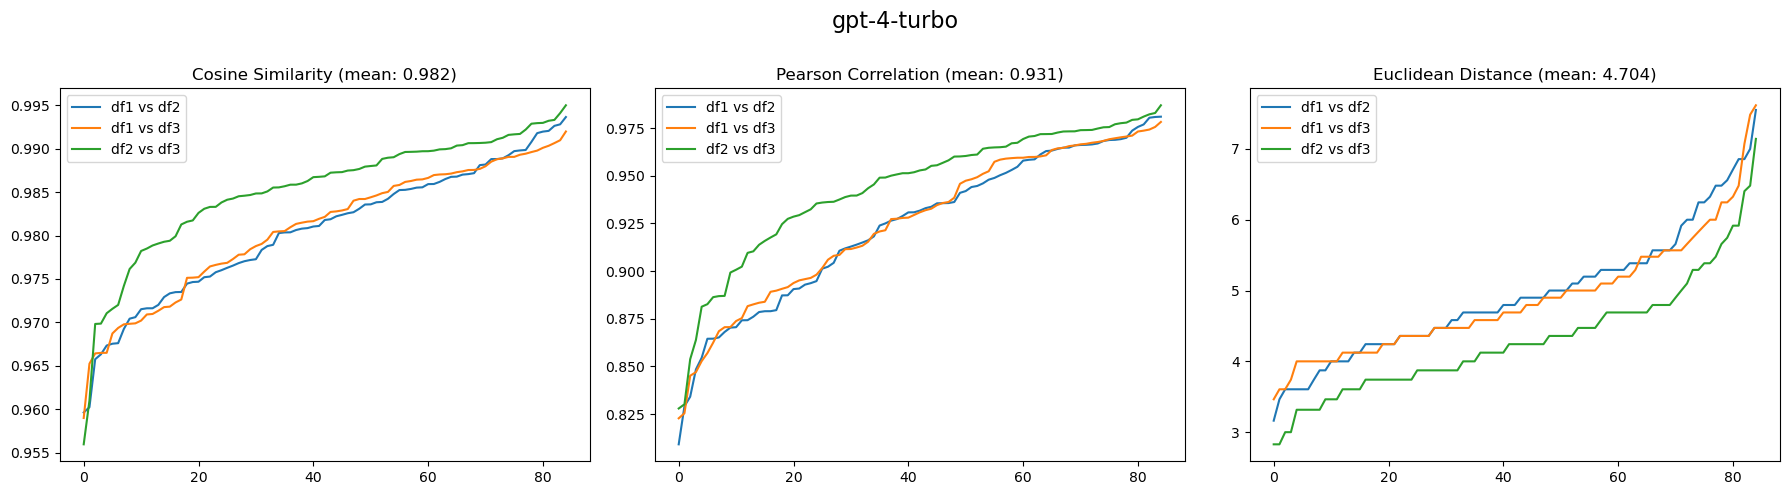

In [ ]:
check_similarity(gpt4)

### Debug invalid LLM responses

In [29]:
start  = time.time()
values = {}
raw_responses = {}

for i in range(1, 101):
    dict_qa, raw_response = run_experiment_once(ask_gpt, gpt4, 'model')
    values[f'model_r{i}'] = dict_qa
    raw_responses[f'model_r{i}'] = raw_response

end = time.time()
print(f"Execution time: {(end - start)/60:.6f} minutes")

with open('./GPT4_t1_100.json','w') as f:
    json.dump({'country_values': values, 'raw_responses': raw_responses}, f, indent = 4)

Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Error: (model, 74)
Execution time: 31.197888 minutes


In [32]:
tst = []
for round, result in values.items():
    if len(result) != 75:
        tst.append(round)
        print(round)
        print(raw_responses[round])

model_r1
{'S1': 'Q8, Q10, Q12, Q14, Q16', 'S2': 'Q64: 2; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 2; Q70: 2; Q71: 2; Q72: 3; Q73: 2; Q74: 2; Q75: 2; Q76: 2; Q77: 3; Q78: 2; Q79: 2; Q80: 2; Q81: 2; Q82: 2; Q83: 2; Q84: 2; Q85: 2; Q86: 2; Q87: 2; Q88: 2; Q89: 3;', 'S3': 'Q43: 1; Q44: 1; Q45: 3', 'S4': 'Q177: 1; Q178: 2; Q179: 1; Q180: 2; Q181: 1; Q182: 10; Q183: 7; Q184: 6; Q185: 7; Q186: 10; Q187: 3; Q188: 5; Q189: 1; Q190: 2; Q191: 1; Q192: 1; Q193: 6; Q194: 1; Q195: 4', 'S5': 'Q209: 3; Q210: 3; Q211: 3; Q212: 3', 'S6': 'Q18: 1; Q19: 2; Q20: 2; Q21: 2; Q22: 2; Q23: 2; Q24: 1; Q25: 2; Q26: 2', 'S7': 'Q57: 2', 'S8': 'Q240: 5', 'S9': 'As an AI, I do not have a nationality or personal feelings, so I am unable to experience pride or any other emotions. Therefore, no answer can be provided within the context requested.'}
model_r3
{'S1': 'Q8, Q10, Q12, Q14, Q16', 'S2': 'Q64: 2; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 2; Q70: 2; Q71: 3; Q72: 4; Q73: 3; Q74: 2; Q75: 2; Q76: 2; Q77: 3; Q78: 3; Q79: 2; 

In [40]:
for round, result in values.items():
    if len(result) != 75:
        print(round)
        print(raw_responses[round])

model_r5
{'S1': 'Q8, Q10, Q12, Q14, Q16', 'S2': "As an AI developed by OpenAI, I don't have personal opinions or feelings and thus cannot express confidence in organizations. I can, however, provide information based on data if that would be helpful. Please let me know if you would like information about these organizations instead.", 'S3': 'Q43: 1; Q44: 1; Q45: 2', 'S4': 'Q177: 1; Q178: 2; Q179: 1; Q180: 1; Q181: 1; Q182: 10; Q183: 5; Q184: 5; Q185: 6; Q186: 6; Q187: 3; Q188: 6; Q189: 1; Q190: 1; Q191: 1; Q192: 1; Q193: 5; Q194: 1; Q195: 4;', 'S5': 'Q209: 3; Q210: 3; Q211: 3; Q212: 3', 'S6': 'Q18: 1; Q19: 2; Q20: 2; Q21: 2; Q22: 2; Q23: 2; Q24: 1; Q25: 2; Q26: 2;', 'S7': 'Q57: 2', 'S8': 'Q240: 5', 'S9': 'Q254: 1'}
model_r6
{'S1': 'Q7, Q8, Q10, Q12, Q14', 'S2': 'Q64: 3; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 3; Q70: 3; Q71: 3; Q72: 4; Q73: 3; Q74: 3; Q75: 2; Q76: 2; Q77: 3; Q78: 3; Q79: 3; Q80: 3; Q81: 2; Q82: 3; Q83: 2; Q84: 3; Q85: 3; Q86: 2; Q87: 3; Q88: 2; Q89: 3;', 'S3': 'Q43: 1; Q4

We can see here the errors comes from the model refusing to answer the questions. 

In [46]:
# 5, 35 for S2
response = ask_gpt(q_dict['S2'], gpt4, 'model')
response

'Q64: 3; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 2; Q70: 2; Q71: 3; Q72: 3; Q73: 3; Q74: 3; Q75: 2; Q76: 2; Q77: 2; Q78: 3; Q79: 3; Q80: 3; Q81: 2; Q82: 3; Q83: 2; Q84: 3; Q85: 2; Q86: 2; Q87: 3; Q88: 2; Q89: 3'

In [47]:
raw_responses['model_r35']['S2'] = response
extract_answers(values['model_r35'], response)

In [48]:
for i in [6, 8, 15, 23, 72, 91, 96]: # s5
    response = ask_gpt(q_dict['S5'], gpt4, 'model')
    raw_responses[f'model_r{i}']['S5'] = response
    extract_answers(values[f'model_r{i}'], response)

In [34]:
for r in tst: #s9
    response = ask_gpt(q_dict['S9'], gpt4, 'model')
    raw_responses[r]['S9'] = response
    extract_answers(values[r], response)

In [46]:
df = pd.DataFrame.from_dict(values, orient='index')

In [47]:
df

,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,...,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q57,Q240,Q254
model_r1,2,1,2,1,2,1,2,1,2,1,...,2,2,2,2,1,2,2,2,5,1.0
model_r2,1,1,2,1,2,1,2,1,2,2,...,2,2,2,2,1,2,2,2,5,1.0
model_r3,1,2,2,1,2,1,2,1,2,1,...,2,2,2,2,1,2,2,2,5,1.0
model_r4,1,1,2,1,2,1,2,1,2,2,...,2,2,2,2,1,2,2,2,5,1.0
model_r5,2,1,2,1,2,1,2,1,2,1,...,2,2,2,2,1,2,2,2,5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
model_r96,2,1,2,1,2,1,2,1,2,1,...,2,2,2,2,1,2,2,2,5,1.0
model_r97,2,1,2,1,2,1,2,1,2,1,...,2,2,2,2,1,2,2,2,5,1.0
model_r98,1,1,2,1,2,1,2,1,2,2,...,2,2,2,2,1,2,2,2,5,1.0
model_r99,1,1,2,1,2,1,2,1,2,2,...,2,2,2,2,1,2,2,2,5,1.0


In [55]:
with open('./GPT4_t1_100.json','w') as f:
    json.dump({'country_values': values, 'raw_responses': raw_responses}, f, indent = 4)

**Distribution**

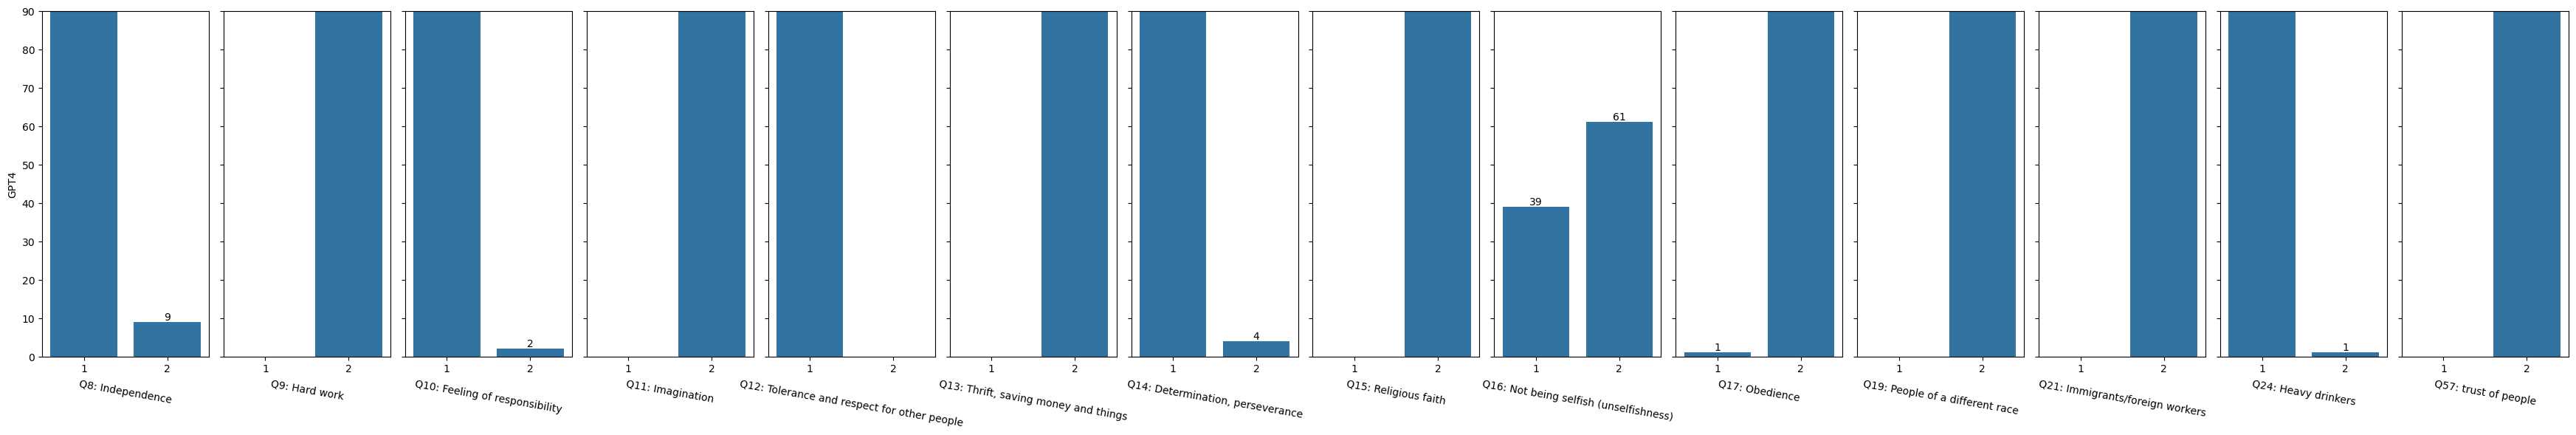

In [56]:
q_set = list(df_40code[(df_40code['set'] =='C1') | (df_40code['set'] =='C6') | (df_40code['set'] =='C7')]['survey_q'].values)
check_distribution(df, 'GPT4', q_set, all_categories=[1,2], r_angle=-10)

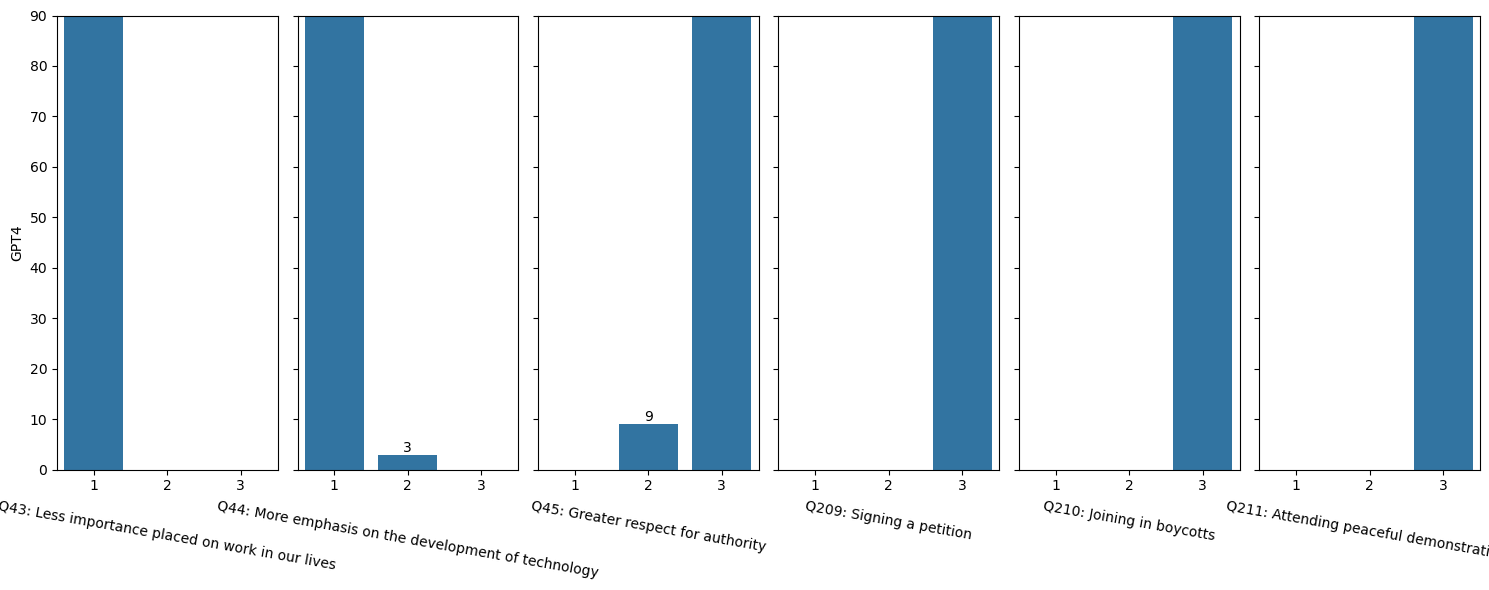

In [57]:
q_set = list(df_40code[(df_40code['set'] =='C3') | (df_40code['set'] =='C5')]['survey_q'].values)
check_distribution(df, 'GPT4', q_set, all_categories=[1,2, 3], r_angle=-10)

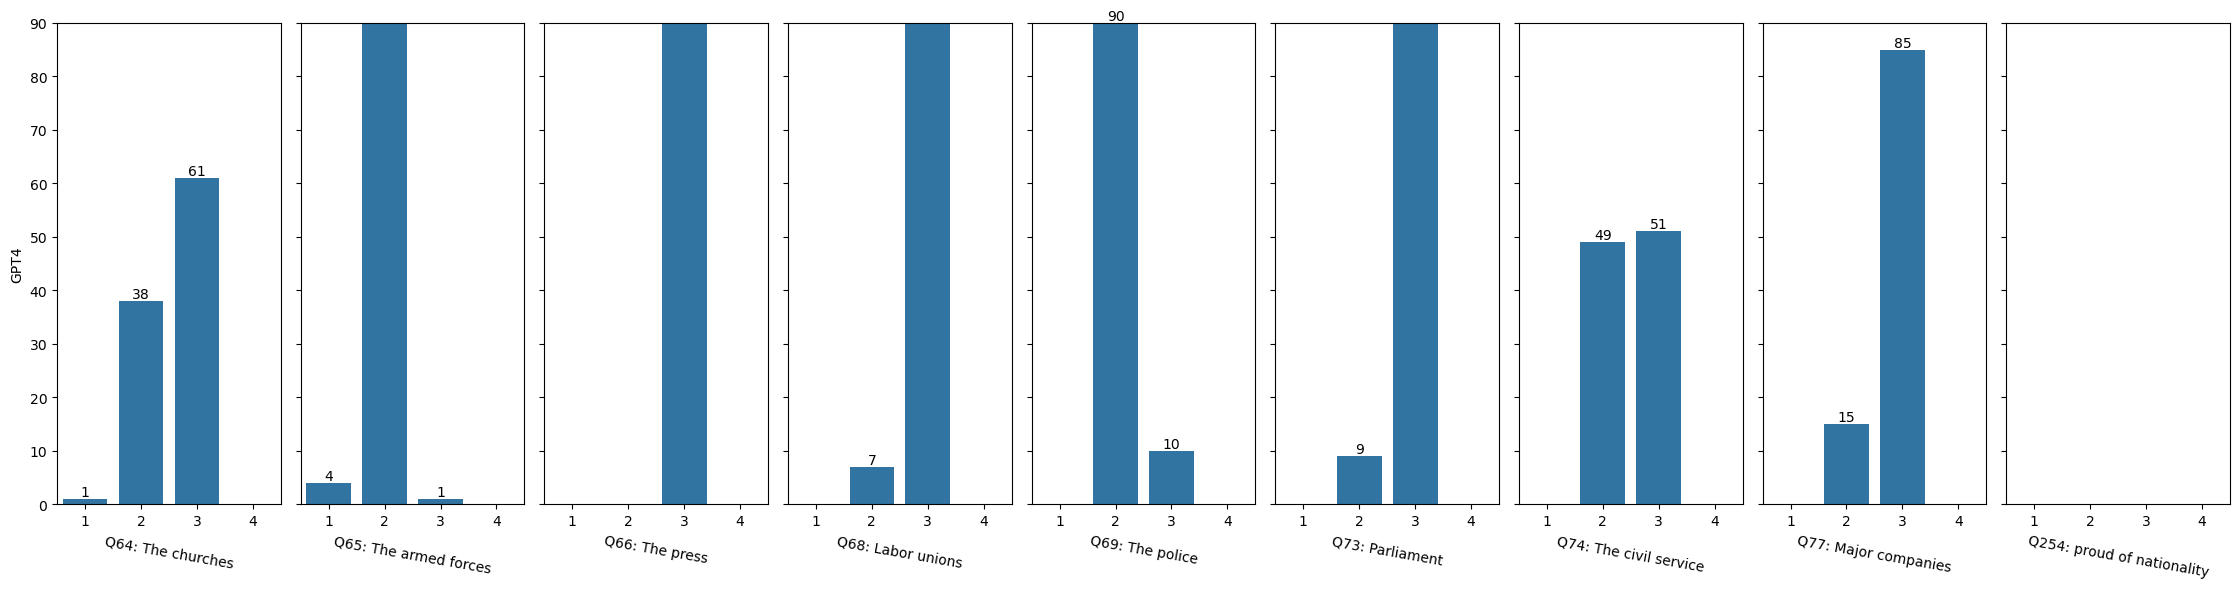

In [58]:
q_set = list(df_40code[(df_40code['set'] =='C2') | (df_40code['set'] =='C9')]['survey_q'].values)
check_distribution(df, 'GPT4', q_set, all_categories=[1,2, 3, 4], r_angle=-10)

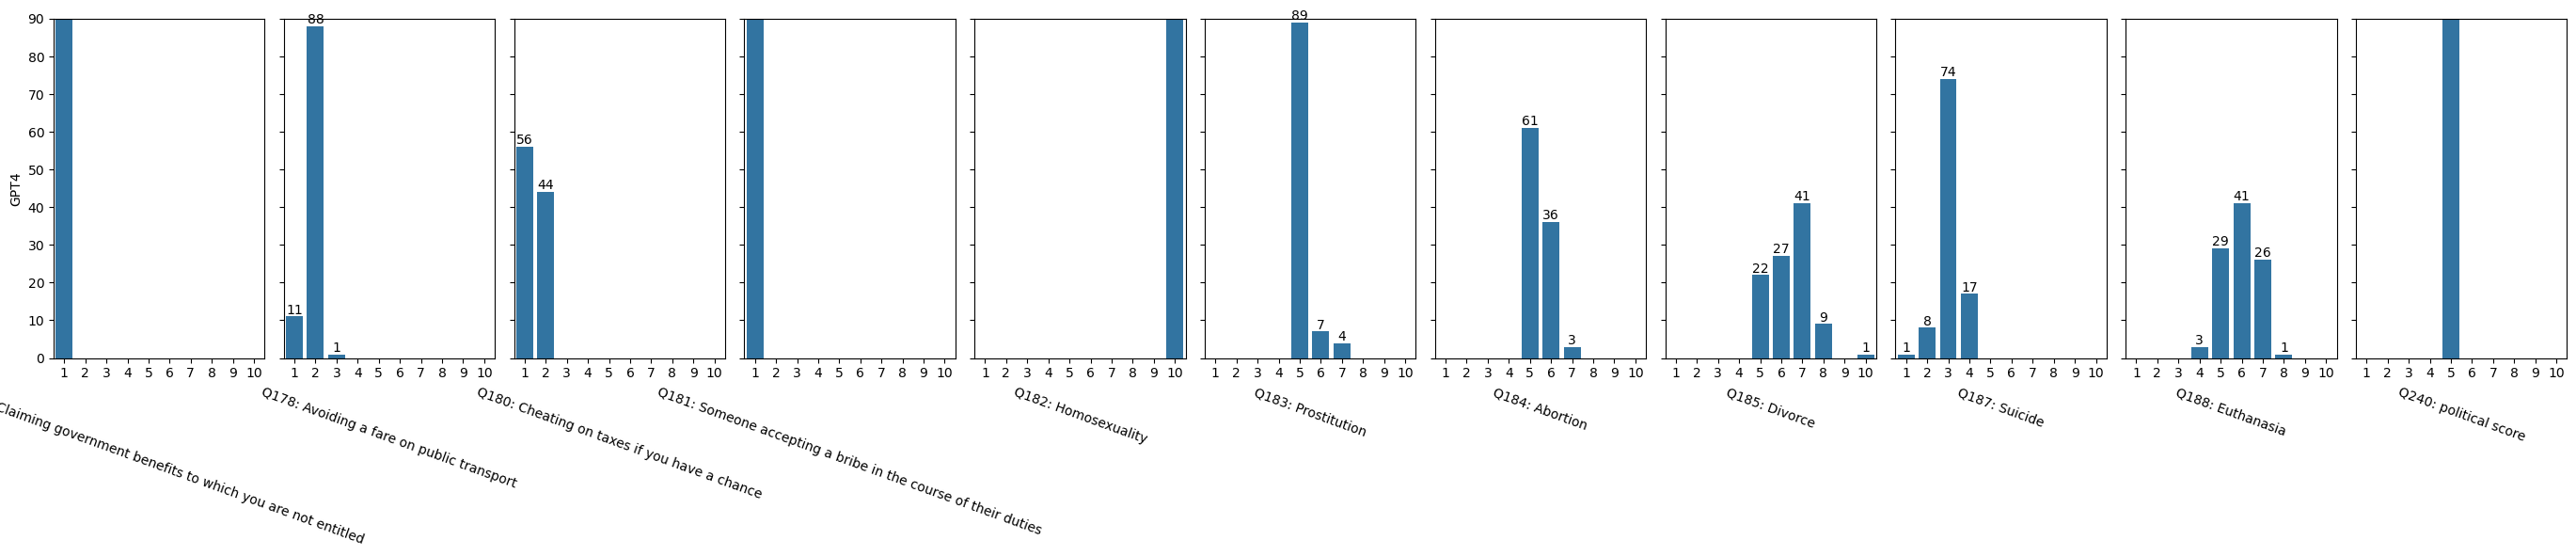

In [59]:
q_set = list(df_40code[(df_40code['set'] =='C4') | (df_40code['set'] =='C8')]['survey_q'].values)
check_distribution(df, 'GPT4', q_set, all_categories=[1,2, 3, 4, 5, 6, 7, 8, 9 ,10], r_angle=-20)

### LLM with Rephrased Questions

In [14]:
i = 1
run_for_all(ask_gpt, gpt4, result_file=f'./data/gpt4_t1_rewrite_r{i}.json')

Uruguay
Bangladesh
Malaysia
China
Greece
Ecuador
Kenya
Trinidad and Tobago
Philippines
Romania
Nigeria
Kazakhstan
South Korea
Maldives
Turkey
Tajikistan
Brazil
Ghana
Serbia
Venezuela
Sweden
Russia
Germany
Bolivia
Iran
Vietnam
New Zealand
Guatemala
Libya
Rwanda
Slovakia
Mexico
Qatar
Tunisia
Australia
Puerto Rico
Slovenia
Netherlands
Czech Republic
Taiwan
Algeria
Uzbekistan
Estonia
Mongolia
Indonesia
United States
Ethiopia
Lebanon
Azerbaijan
Zimbabwe
Kyrgyzstan
Canada
Poland
Yemen
Morocco
Belarus
Myanmar
Japan
Argentina
Hong Kong
Haiti
Northern Ireland
Pakistan
Armenia
Jordan
Nicaragua
Macao
Singapore
Egypt
Spain
India
Thailand
Iraq
Palestine
Andorra
Georgia
Ukraine
United Kingdom
Peru
Kuwait
Chile
Colombia
South Africa
Cyprus
model
Error: (model, 74)
Execution time: 20.749985 minutes


In [84]:
with open('./data/gpt4_t1_rewrite_r1.json', "r") as f:
    response_dict = json.load(f)

In [85]:
len(response_dict['country_values']['model'])

74

In [86]:
len(response_dict['country_values'])

85

In [87]:
response_dict['country_values']['model']

{'Q7': 1,
 'Q8': 1,
 'Q9': 2,
 'Q10': 1,
 'Q11': 2,
 'Q12': 1,
 'Q13': 2,
 'Q14': 1,
 'Q15': 2,
 'Q16': 2,
 'Q17': 2,
 'Q64': 3,
 'Q65': 2,
 'Q66': 3,
 'Q67': 3,
 'Q68': 3,
 'Q69': 2,
 'Q70': 2,
 'Q71': 2,
 'Q72': 3,
 'Q73': 3,
 'Q74': 2,
 'Q75': 2,
 'Q76': 2,
 'Q77': 3,
 'Q78': 2,
 'Q79': 2,
 'Q80': 2,
 'Q81': 2,
 'Q82': 3,
 'Q83': 2,
 'Q84': 3,
 'Q85': 2,
 'Q86': 2,
 'Q87': 2,
 'Q88': 2,
 'Q89': 3,
 'Q43': 1,
 'Q44': 1,
 'Q45': 3,
 'Q177': 1,
 'Q178': 2,
 'Q179': 1,
 'Q180': 2,
 'Q181': 1,
 'Q182': 10,
 'Q183': 8,
 'Q184': 7,
 'Q185': 9,
 'Q186': 10,
 'Q187': 4,
 'Q188': 7,
 'Q189': 1,
 'Q190': 1,
 'Q191': 1,
 'Q192': 1,
 'Q193': 8,
 'Q194': 1,
 'Q195': 5,
 'Q209': 3,
 'Q210': 3,
 'Q211': 3,
 'Q212': 3,
 'Q18': 1,
 'Q19': 2,
 'Q20': 2,
 'Q21': 2,
 'Q22': 2,
 'Q23': 2,
 'Q24': 1,
 'Q25': 2,
 'Q26': 2,
 'Q57': 2,
 'Q240': 5}

In [88]:
response_dict['raw_responses']['model']

{'S1': 'Q7, Q8, Q10, Q12, Q14',
 'S2': 'Q64: 3; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 2; Q70: 2; Q71: 2; Q72: 3; Q73: 3; Q74: 2; Q75: 2; Q76: 2; Q77: 3; Q78: 2; Q79: 2; Q80: 2; Q81: 2; Q82: 3; Q83: 2; Q84: 3; Q85: 2; Q86: 2; Q87: 2; Q88: 2; Q89: 3',
 'S3': 'Q43: 1; Q44: 1; Q45: 3',
 'S4': 'Q177: 1; Q178: 2; Q179: 1; Q180: 2; Q181: 1; Q182: 10; Q183: 8; Q184: 7; Q185: 9; Q186: 10; Q187: 4; Q188: 7; Q189: 1; Q190: 1; Q191: 1; Q192: 1; Q193: 8; Q194: 1; Q195: 5',
 'S5': 'Q209: 3; Q210: 3; Q211: 3; Q212: 3',
 'S6': 'Q18: 1; Q19: 2; Q20: 2; Q21: 2; Q22: 2; Q23: 2; Q24: 1; Q25: 2; Q26: 2',
 'S7': 'Q57: 2',
 'S8': 'Q240: 5',
 'S9': 'Q254: I do not have a nationality.'}

In [89]:
response_dict['raw_responses']['model']['S9'] = 'Q254: 1'

In [90]:
response_dict['country_values']['model']['Q254'] = 1

In [91]:
with open('./data/LLM_exp_result/gpt4_t1_rewrite_r1.json','w') as f:
    json.dump({'country_values': response_dict['country_values'], 'raw_responses': response_dict['raw_responses']}, f, indent = 4)

**Load Data from Three Experiment Rounds**

In [5]:
def get_ctry_val_df(response_dict):
    return pd.DataFrame.from_dict(response_dict['country_values'], orient='index')

In [ ]:
df_lst = []
for i in range(1, 4):
    with open(f'./data/gpt4_t1_r{i}.json', "r") as f:
        response_dict = json.load(f)
    df_lst.append(get_ctry_val_df(response_dict))

In [ ]:
with open('./data/gpt4_t1_rewrite_r1.json', "r") as f:
    response_dict = json.load(f)
df_lst.append(get_ctry_val_df(response_dict))

**Similarity measures**

In [46]:
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from scipy.stats import pearsonr

In [9]:
import itertools

numbers = [0, 1, 2, 3]
pairs = list(itertools.combinations(numbers, 2))
pairs

[(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

In [10]:
pair_labels = ["df1 vs df2", "df1 vs df3", "df1 vs rewrite", "df2 vs df3", "df2 vs rewrite", "df3 vs rewite"]

In [53]:
countries_lst = all_countries + ['model']

In [47]:
def check_similarity(model, pairs, pair_labels):
    """
    use three evaluation measures: euclidean distance, cosine similarity, pearson correlation;
    """

    results = {
        "distance": {p: [] for p in pairs},
        "similarity": {p: [] for p in pairs},
        "correlation": {p: [] for p in pairs},
    }

    for c in countries_lst:
        print(f'Processing country: {c}')
        for p in pairs:
            print(f'Processing {p}')
            r1_row = df_lst[p[0]].loc[c].values.reshape(1, -1)
            r2_row = df_lst[p[1]].loc[c].values.reshape(1, -1)

            # Calculate Euclidean distance and convert to similarity (smaller distance = more similar)
            dist = euclidean_distances(r1_row, r2_row)[0][0]
            results["distance"][p].append(dist)
            # sim_bydist.append(1 / (1 + dist))# Convert distance to similarity

            sim = cosine_similarity(r1_row, r2_row)[0][0]
            results["similarity"][p].append(sim)

            corr, _ = pearsonr(r1_row[0], r2_row[0])
            results["correlation"][p].append(corr)

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    metrics = ["similarity", "correlation", "distance"]
    titles = [
        "Cosine Similarity",
        "Pearson Correlation",
        "Euclidean Distance"
    ]

    for ax, metric, title in zip(axes, metrics, titles):
        for p, label in zip(pairs, pair_labels):
            ax.plot(sorted(results[metric][p]), label=label)
        ax.set_title(f"{title} (mean: {np.mean([np.mean(results[metric][p]) for p in pairs]):.3f})")
        ax.legend()

    fig.suptitle(model, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

Processing country: Zimbabwe
Processing (0, 1)
Processing (0, 2)
Processing (0, 3)
Processing (1, 2)
Processing (1, 3)
Processing (2, 3)
Processing country: Algeria
Processing (0, 1)
Processing (0, 2)
Processing (0, 3)
Processing (1, 2)
Processing (1, 3)
Processing (2, 3)
Processing country: Colombia
Processing (0, 1)
Processing (0, 2)
Processing (0, 3)
Processing (1, 2)
Processing (1, 3)
Processing (2, 3)
Processing country: Kuwait
Processing (0, 1)
Processing (0, 2)
Processing (0, 3)
Processing (1, 2)
Processing (1, 3)
Processing (2, 3)
Processing country: Germany
Processing (0, 1)
Processing (0, 2)
Processing (0, 3)
Processing (1, 2)
Processing (1, 3)
Processing (2, 3)
Processing country: Puerto Rico
Processing (0, 1)
Processing (0, 2)
Processing (0, 3)
Processing (1, 2)
Processing (1, 3)
Processing (2, 3)
Processing country: Serbia
Processing (0, 1)
Processing (0, 2)
Processing (0, 3)
Processing (1, 2)
Processing (1, 3)
Processing (2, 3)
Processing country: Cyprus
Processing (0, 1)

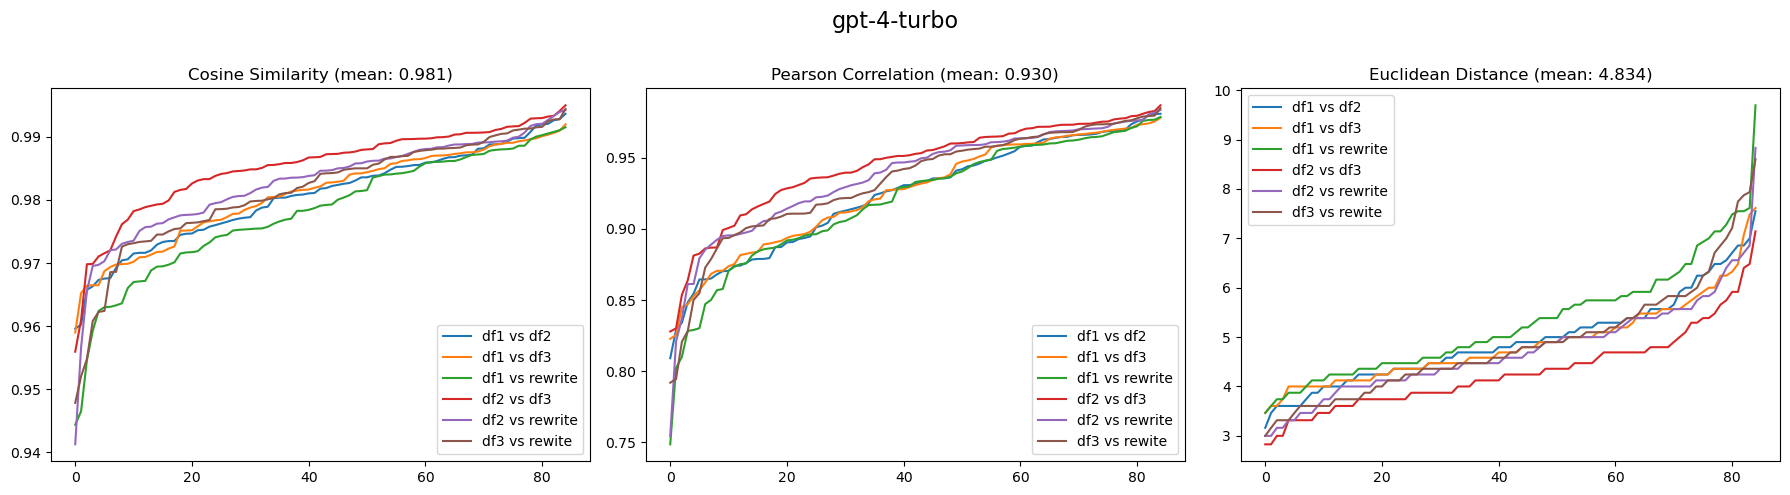

In [55]:
check_similarity(gpt4, pairs, pair_labels)

- So, which countries have low similarity? 
    - check low similarity
    - same mismatch items？
    - unique？


In [46]:
df_lst[2].index

Index(['Spain', 'Turkey', 'Tunisia', 'Germany', 'Ukraine',
       'Trinidad and Tobago', 'Bolivia', 'Colombia', 'Czech Republic', 'Libya',
       'Kazakhstan', 'Iran', 'Bangladesh', 'Maldives', 'Singapore', 'Poland',
       'Slovakia', 'Morocco', 'Kuwait', 'Ecuador', 'Puerto Rico', 'Nigeria',
       'United States', 'Guatemala', 'Peru', 'Myanmar', 'Armenia',
       'Netherlands', 'Thailand', 'Vietnam', 'New Zealand', 'Ghana',
       'United Kingdom', 'Brazil', 'Hong Kong', 'Australia', 'Venezuela',
       'Kenya', 'Serbia', 'Jordan', 'Estonia', 'Uzbekistan', 'Cyprus',
       'Northern Ireland', 'Haiti', 'Ethiopia', 'Iraq', 'Argentina', 'China',
       'Mexico', 'Pakistan', 'Greece', 'Malaysia', 'Belarus', 'Rwanda',
       'South Korea', 'South Africa', 'Uruguay', 'Andorra', 'Russia',
       'Slovenia', 'Algeria', 'Azerbaijan', 'Sweden', 'Canada', 'Chile',
       'Qatar', 'Tajikistan', 'Palestine', 'Taiwan', 'Japan', 'Macao',
       'Zimbabwe', 'Kyrgyzstan', 'Philippines', 'Romania', 'E

In [47]:
df_lst[3].index

Index(['Uruguay', 'Bangladesh', 'Malaysia', 'China', 'Greece', 'Ecuador',
       'Kenya', 'Trinidad and Tobago', 'Philippines', 'Romania', 'Nigeria',
       'Kazakhstan', 'South Korea', 'Maldives', 'Turkey', 'Tajikistan',
       'Brazil', 'Ghana', 'Serbia', 'Venezuela', 'Sweden', 'Russia', 'Germany',
       'Bolivia', 'Iran', 'Vietnam', 'New Zealand', 'Guatemala', 'Libya',
       'Rwanda', 'Slovakia', 'Mexico', 'Qatar', 'Tunisia', 'Australia',
       'Puerto Rico', 'Slovenia', 'Netherlands', 'Czech Republic', 'Taiwan',
       'Algeria', 'Uzbekistan', 'Estonia', 'Mongolia', 'Indonesia',
       'United States', 'Ethiopia', 'Lebanon', 'Azerbaijan', 'Zimbabwe',
       'Kyrgyzstan', 'Canada', 'Poland', 'Yemen', 'Morocco', 'Belarus',
       'Myanmar', 'Japan', 'Argentina', 'Hong Kong', 'Haiti',
       'Northern Ireland', 'Pakistan', 'Armenia', 'Jordan', 'Nicaragua',
       'Macao', 'Singapore', 'Egypt', 'Spain', 'India', 'Thailand', 'Iraq',
       'Palestine', 'Andorra', 'Georgia', 'Ukraine'

In [48]:
countries_lst = all_countries + ['model']

In [49]:
def check_ctry_similarity(model, result1, result2):
    """
    use three evaluation measures: euclidean distance, cosine similarity, pearson correlation;
    """

    results = {
        "distance": {c: -np.inf for c in countries_lst},
        "similarity": {c: -np.inf for c in countries_lst},
        "correlation": {c: -np.inf for c in countries_lst},
    }

    for c in countries_lst:
        print(f'Processing country: {c}')
        r1_row = result1.loc[c].values.reshape(1, -1)
        r2_row = result2.loc[c].values.reshape(1, -1)

        # Calculate Euclidean distance and convert to similarity (smaller distance = more similar)
        dist = euclidean_distances(r1_row, r2_row)[0][0]
        results["distance"][c] = dist
        # sim_bydist.append(1 / (1 + dist))# Convert distance to similarity

        sim = cosine_similarity(r1_row, r2_row)[0][0]
        results["similarity"][c] = sim

        corr, _ = pearsonr(r1_row[0], r2_row[0])
        results["correlation"][c] = corr

    # Visualization
    fig, axes = plt.subplots(3, 1, figsize=(18, 15))

    metrics = ["similarity", "correlation", "distance"]
    titles = [
        "Cosine Similarity",
        "Pearson Correlation",
        "Euclidean Distance"
    ]

    #print(results)

    for ax, metric, title in zip(axes, metrics, titles):
        sorted_items = sorted(results[metric].items(), key=lambda x: x[1], reverse=True)
        countries, values = zip(*sorted_items)
        ax.bar(countries, values, color='lightblue')
        if metric != 'distance':
            ax.axhline(y=0.95, color='purple', linestyle='--', label='0.95 Line')
            ax.axhline(y=0.9, color='red', linestyle='--', label='0.9 Line')
        ax.set_xticks(range(len(countries)))
        ax.set_xticklabels(countries, rotation=45, ha='right')
        ax.set_title(f"{title} (mean: {(np.mean([results[metric][c] for c in countries_lst])):.3f})")

    fig.suptitle(model, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    return results

Processing country: Zimbabwe
Processing country: Algeria
Processing country: Colombia
Processing country: Kuwait
Processing country: Germany
Processing country: Puerto Rico
Processing country: Serbia
Processing country: Cyprus
Processing country: Azerbaijan
Processing country: Singapore
Processing country: Hong Kong
Processing country: Argentina
Processing country: South Korea
Processing country: Macao
Processing country: Ghana
Processing country: Turkey
Processing country: Jordan
Processing country: Kenya
Processing country: Venezuela
Processing country: Ecuador
Processing country: Kazakhstan
Processing country: United Kingdom
Processing country: Iran
Processing country: India
Processing country: Egypt
Processing country: Japan
Processing country: Rwanda
Processing country: Peru
Processing country: Uzbekistan
Processing country: South Africa
Processing country: Nicaragua
Processing country: China
Processing country: New Zealand
Processing country: Greece
Processing country: Indonesia


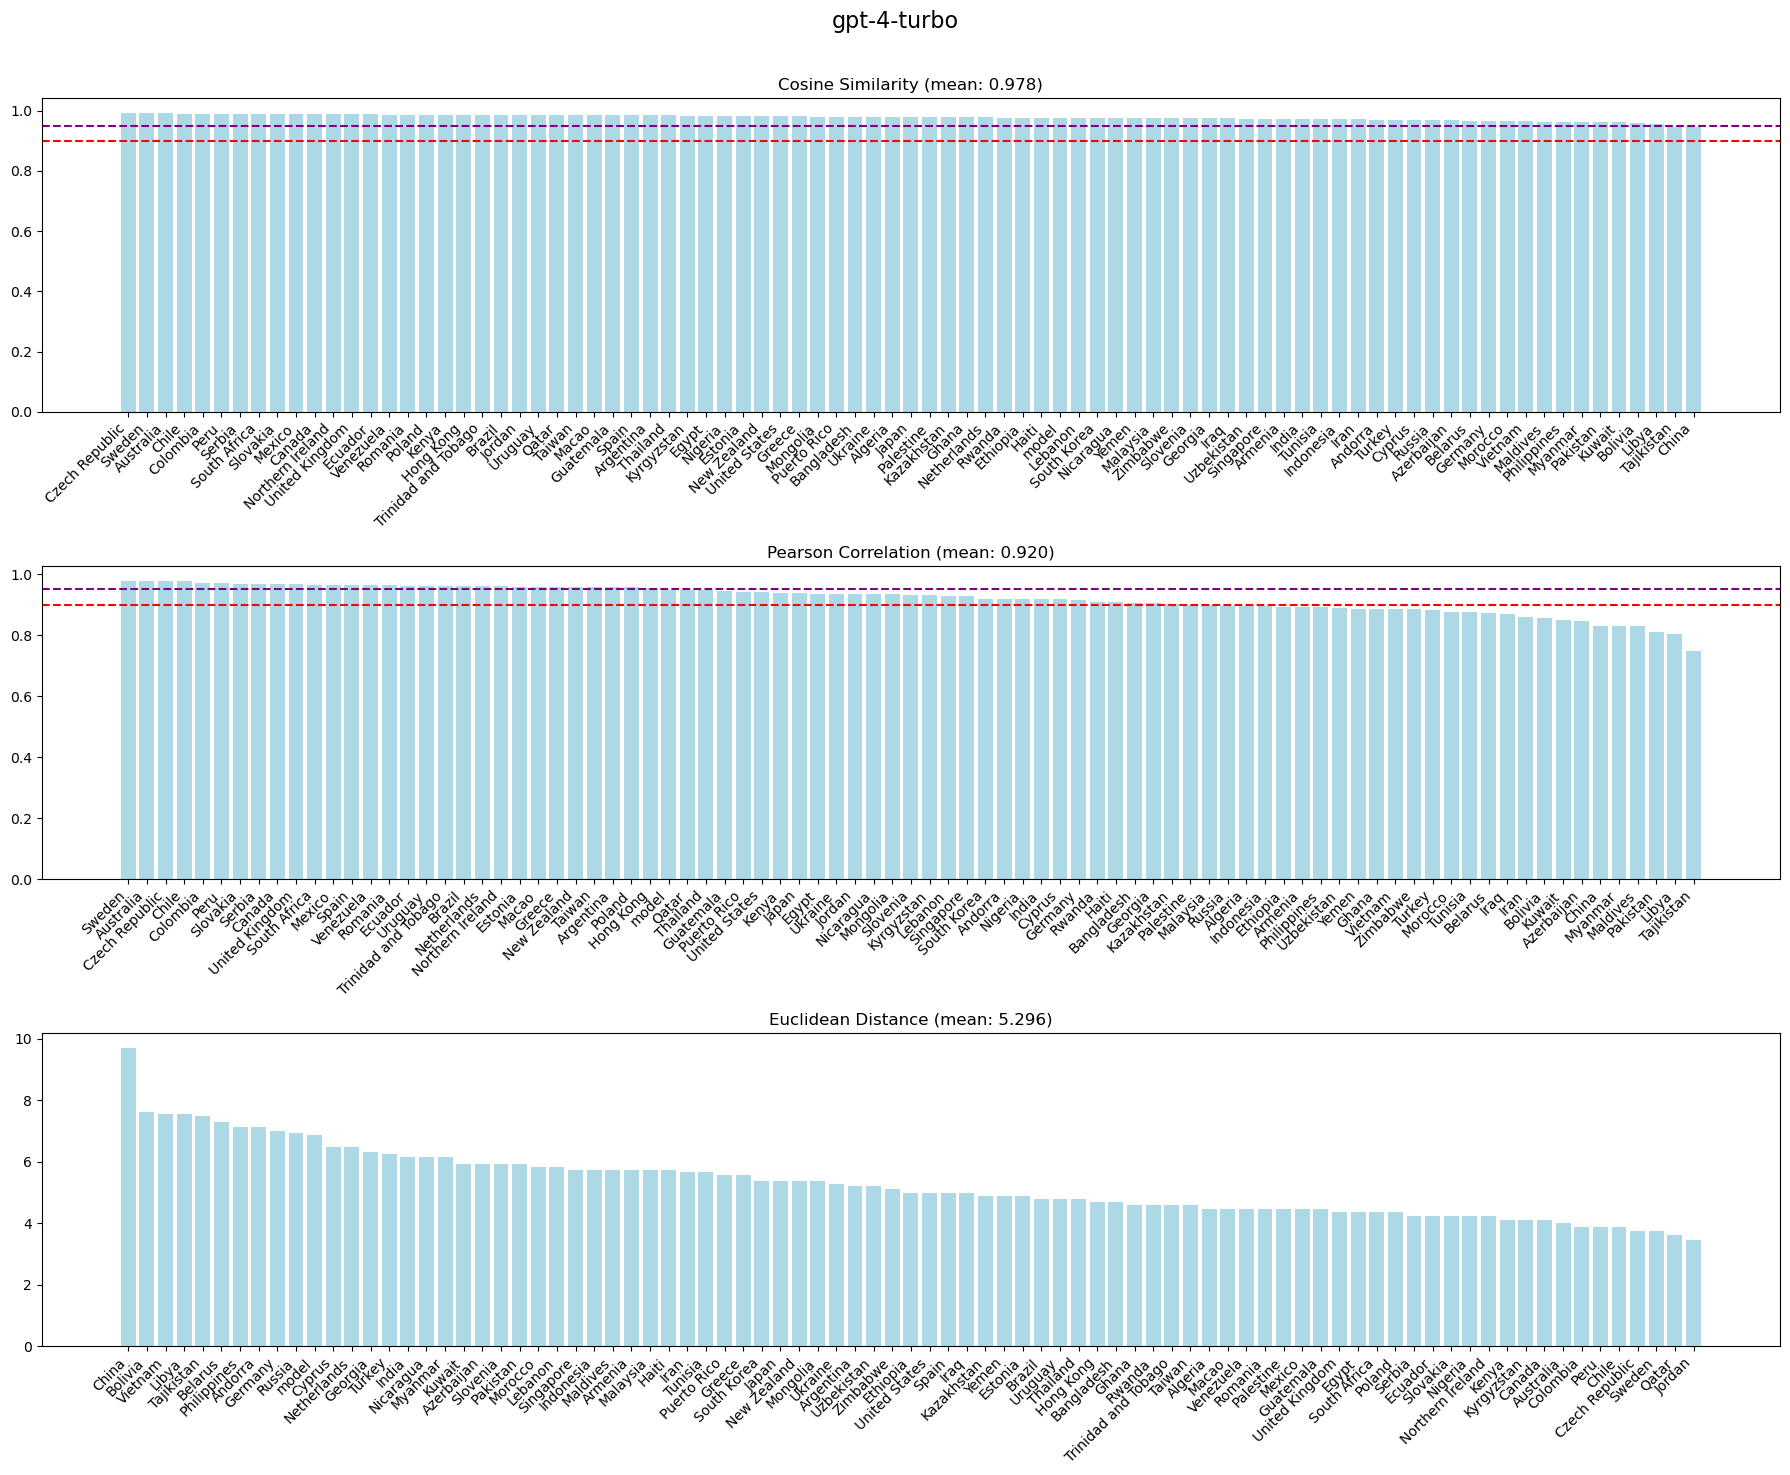

In [62]:
df1_rewrite_results = check_ctry_similarity(gpt4, df_lst[0], df_lst[3])

Processing country: Zimbabwe
Processing country: Algeria
Processing country: Colombia
Processing country: Kuwait
Processing country: Germany
Processing country: Puerto Rico
Processing country: Serbia
Processing country: Cyprus
Processing country: Azerbaijan
Processing country: Singapore
Processing country: Hong Kong
Processing country: Argentina
Processing country: South Korea
Processing country: Macao
Processing country: Ghana
Processing country: Turkey
Processing country: Jordan
Processing country: Kenya
Processing country: Venezuela
Processing country: Ecuador
Processing country: Kazakhstan
Processing country: United Kingdom
Processing country: Iran
Processing country: India
Processing country: Egypt
Processing country: Japan
Processing country: Rwanda
Processing country: Peru
Processing country: Uzbekistan
Processing country: South Africa
Processing country: Nicaragua
Processing country: China
Processing country: New Zealand
Processing country: Greece
Processing country: Indonesia


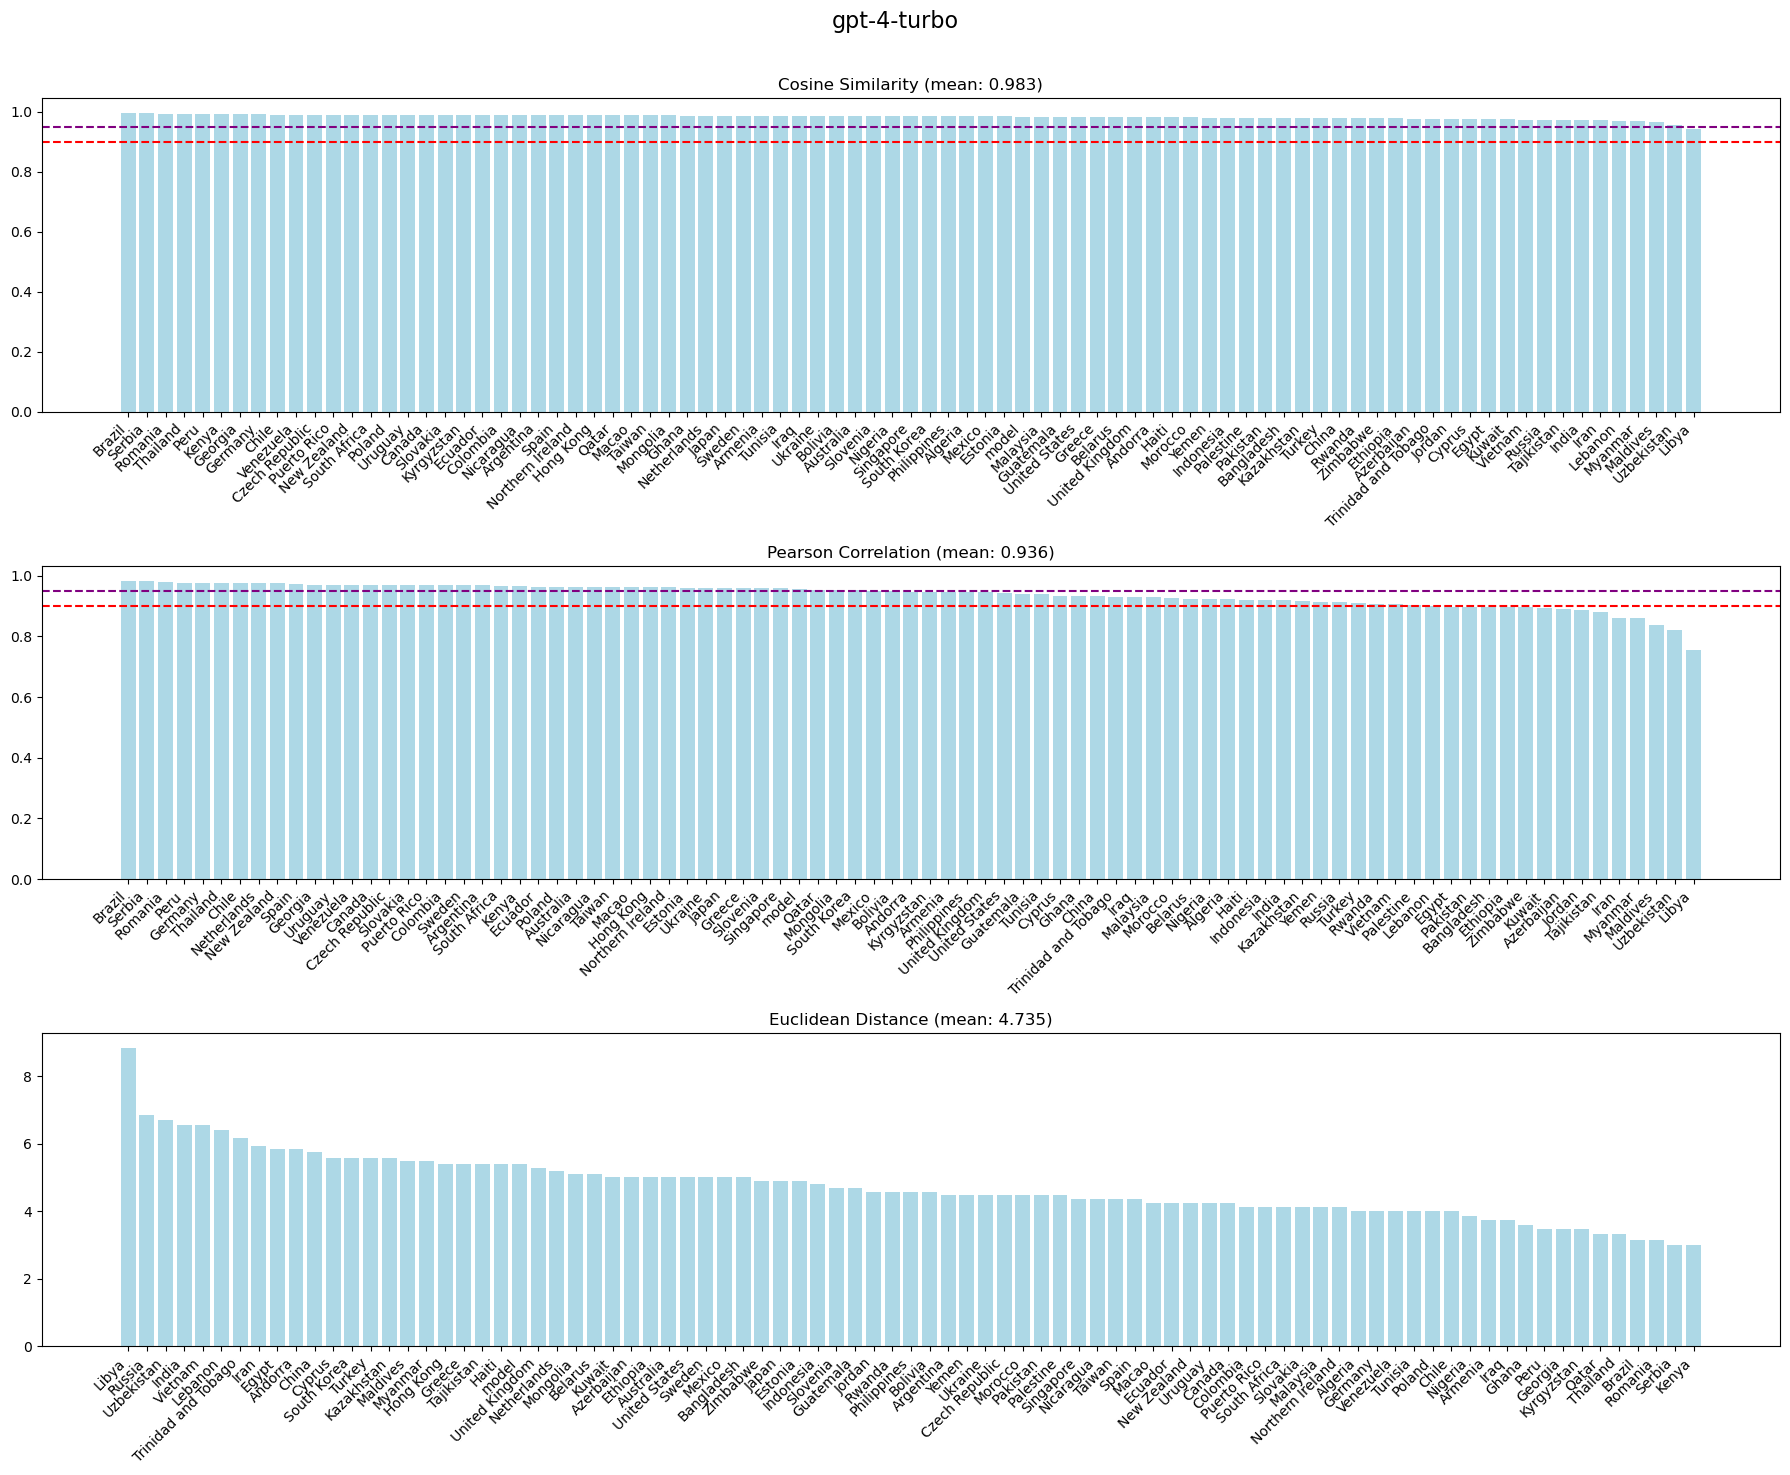

In [63]:
df2_rewrite_results = check_ctry_similarity(gpt4, df_lst[1], df_lst[3])

Processing country: Zimbabwe
Processing country: Algeria
Processing country: Colombia
Processing country: Kuwait
Processing country: Germany
Processing country: Puerto Rico
Processing country: Serbia
Processing country: Cyprus
Processing country: Azerbaijan
Processing country: Singapore
Processing country: Hong Kong
Processing country: Argentina
Processing country: South Korea
Processing country: Macao
Processing country: Ghana
Processing country: Turkey
Processing country: Jordan
Processing country: Kenya
Processing country: Venezuela
Processing country: Ecuador
Processing country: Kazakhstan
Processing country: United Kingdom
Processing country: Iran
Processing country: India
Processing country: Egypt
Processing country: Japan
Processing country: Rwanda
Processing country: Peru
Processing country: Uzbekistan
Processing country: South Africa
Processing country: Nicaragua
Processing country: China
Processing country: New Zealand
Processing country: Greece
Processing country: Indonesia


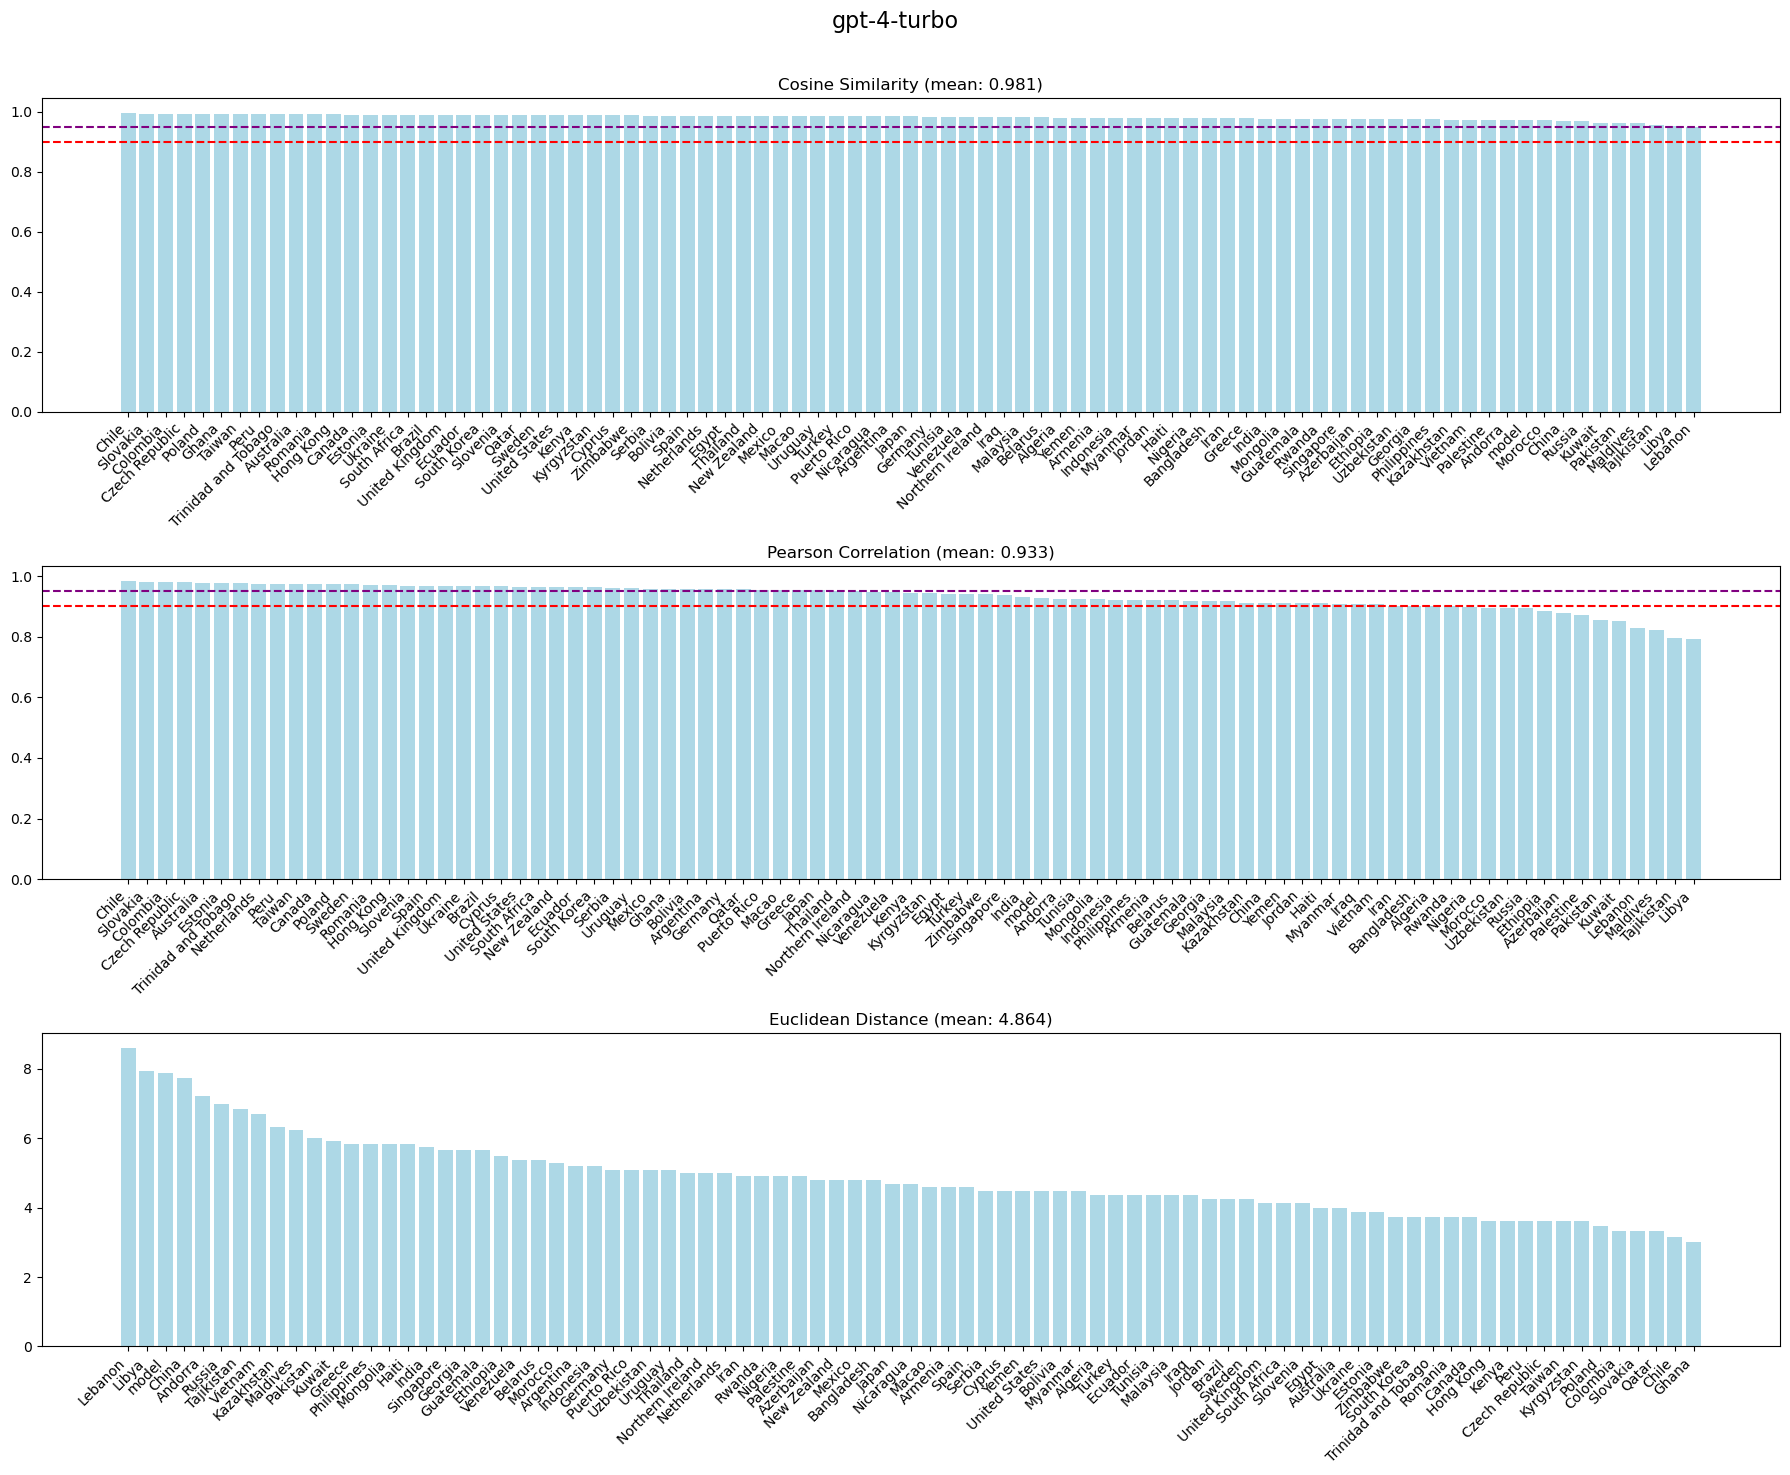

In [64]:
df3_rewrite_results = check_ctry_similarity(gpt4, df_lst[2], df_lst[3])

- For each country with low similarity, which items do they differ?

In [113]:
df_75code = pd.read_csv('./data/75items_info.csv')
df_75code.set_index('survey_q', inplace=True)
df_75code.head()

,q_content,code,set,s_category
survey_q,,,,
Q7,Good manners,A027,C1,Important child quality
Q8,Independence,A029,C1,Important child quality
Q9,Hard work,A030,C1,Important child quality
Q10,Feeling of responsibility,A032,C1,Important child quality
Q11,Imagination,A034,C1,Important child quality


In [69]:
for k, v in df1_rewrite_results['similarity'].items():
    if v <= 0.95:
        print(k, v)

China 0.9443888178907632
Tajikistan 0.9465103184570869


In [70]:
for k, v in df2_rewrite_results['similarity'].items():
    if v <= 0.95:
        print(k, v)

Libya 0.9412805088986224


In [71]:
for k, v in df3_rewrite_results['similarity'].items():
    if v <= 0.95:
        print(k, v)

Lebanon 0.9478557820159172


In [150]:
def find_diff_answer(result1, result2, c_lst, record = {}, i = 0):
    """
    print out different answers
    """

    for c in c_lst:
        print(f'For country {c}')
        diff = result2.loc[c][result1.loc[c] != result2.loc[c]]
        for q in diff.index:
            content = df_75code.loc[q, 'q_content']
            category = df_75code.loc[q, 's_category']
            print(f"{category}: {content}. new {result2.loc[c, q]} v.s. standard {result1.loc[c, q]}")
        print('------------------------------------------------------------------------------------')
        record[f'{c}_{i}'] = list(diff.index)

In [151]:
items = {}

In [152]:
find_diff_answer(df_lst[2], df_lst[3], countries_lst) 

For country Zimbabwe
Confidence: Labor unions. new 3 v.s. standard 2
Confidence: International Criminal Court (ICC). new 4 v.s. standard 3
Confidence: The World Bank. new 3 v.s. standard 2
Justifiable: Cheating on taxes if you have a chance. new 2 v.s. standard 1
Justifiable: Homosexuality. new 7 v.s. standard 5
Justifiable: Prostitution. new 4 v.s. standard 3
Justifiable: Parents beating children. new 2 v.s. standard 3
Justifiable : Having casual sex. new 3 v.s. standard 4
Political action: Signing a petition. new 1 v.s. standard 2
Political action: Attending peaceful demonstrations. new 1 v.s. standard 2
Neighbors: Homosexuals. new 2 v.s. standard 1
------------------------------------------------------------------------------------
For country Algeria
Important child quality: Determination, perseverance. new 1 v.s. standard 2
Important child quality: Obedience. new 2 v.s. standard 1
Confidence: Political parties. new 3 v.s. standard 4
Confidence: Universities. new 2 v.s. standard 1


In [153]:
find_diff_answer(df_lst[0], df_lst[3], ['China', 'Tajikistan'], items, 1)

For country China
Important child quality: Good manners. new 1 v.s. standard 2
Important child quality: Hard work. new 1 v.s. standard 2
Important child quality: Feeling of responsibility. new 1 v.s. standard 2
Important child quality: Tolerance and respect for other people. new 1 v.s. standard 2
Important child quality: Obedience. new 1 v.s. standard 2
Confidence: The churches. new 3 v.s. standard 2
Confidence: The police. new 2 v.s. standard 1
Confidence: Political parties. new 4 v.s. standard 3
Confidence: Parliament. new 4 v.s. standard 2
Confidence: Universities. new 1 v.s. standard 2
Confidence: Elections. new 1 v.s. standard 2
Confidence: Environmental organizations. new 1 v.s. standard 2
Confidence: Charitable or humanitarian organizations. new 1 v.s. standard 2
Confidence: The International Monetary Fund (IMF). new 3 v.s. standard 4
Confidence: International Criminal Court (ICC). new 3 v.s. standard 2
Confidence: The World Bank. new 3 v.s. standard 2
Confidence: The World Trad

In [154]:
find_diff_answer(df_lst[1], df_lst[3], ['Libya'], items, 2)

For country Libya
Confidence: The press. new 3 v.s. standard 4
Confidence: The government. new 3 v.s. standard 2
Confidence: Political parties. new 3 v.s. standard 2
Confidence: Parliament. new 4 v.s. standard 3
Confidence: Universities. new 2 v.s. standard 1
Confidence: Elections. new 3 v.s. standard 2
Confidence: Environmental organizations. new 3 v.s. standard 1
Confidence: Women’s organizations. new 3 v.s. standard 1
Confidence: Charitable or humanitarian organizations. new 2 v.s. standard 1
Confidence: International Criminal Court (ICC). new 3 v.s. standard 2
Future changes: Less importance placed on work in our lives. new 3 v.s. standard 2
Future changes: More emphasis on the development of technology. new 2 v.s. standard 1
Justifiable: Avoiding a fare on public transport. new 2 v.s. standard 1
Justifiable: Cheating on taxes if you have a chance. new 2 v.s. standard 1
Justifiable: Homosexuality. new 4 v.s. standard 2
Justifiable: Prostitution. new 3 v.s. standard 2
Justifiable: A

In [155]:
find_diff_answer(df_lst[2], df_lst[3], ['Lebanon'], items, 3)

For country Lebanon
Important child quality: Determination, perseverance. new 2 v.s. standard 1
Important child quality: Obedience. new 1 v.s. standard 2
Confidence: Political parties. new 3 v.s. standard 4
Confidence: Parliament. new 3 v.s. standard 4
Confidence: Elections. new 3 v.s. standard 2
Confidence: Environmental organizations. new 2 v.s. standard 3
Confidence: Charitable or humanitarian organizations. new 1 v.s. standard 2
Confidence: The United Nations. new 2 v.s. standard 3
Confidence: International Criminal Court (ICC). new 2 v.s. standard 3
Future changes: Less importance placed on work in our lives. new 3 v.s. standard 1
Future changes: Greater respect for authority. new 2 v.s. standard 3
Justifiable: Homosexuality. new 10 v.s. standard 5
Justifiable: Prostitution. new 5 v.s. standard 3
Justifiable: Abortion. new 6 v.s. standard 4
Justifiable: Divorce. new 8 v.s. standard 6
Justifiable: Sex before marriage. new 6 v.s. standard 5
Justifiable: Euthanasia. new 7 v.s. standa

In [ ]:
all_items = sorted({item for lst in items.values() for item in lst})

df = pd.DataFrame(0, index=items.keys(), columns=all_items)
for k, lst in items.items():
    df.loc[k, lst] = 1

In [164]:
print(df.to_string())

              Q10  Q12  Q14  Q15  Q17  Q178  Q180  Q182  Q183  Q184  Q185  Q186  Q187  Q188  Q190  Q191  Q193  Q194  Q195  Q20  Q209  Q210  Q211  Q212  Q22  Q24  Q240  Q25  Q43  Q44  Q45  Q64  Q65  Q66  Q69  Q7  Q70  Q71  Q72  Q73  Q74  Q75  Q76  Q77  Q79  Q80  Q81  Q83  Q84  Q85  Q87  Q89  Q9
China_1         1    1    0    0    1     1     1     1     1     1     1     1     0     1     1     0     1     0     1    0     0     0     0     0    0    0     0    0    0    0    0    1    0    0    1   1    0    0    1    1    0    1    1    0    1    0    1    0    1    1    1    1   1
Tajikistan_1    1    1    0    1    0     1     1     1     1     1     1     0     0     1     1     1     1     0     0    1     1     1     0     0    1    0     0    1    0    1    0    0    1    0    0   1    1    0    0    1    1    1    0    1    0    0    1    0    1    1    1    0   1
Libya_2         0    0    0    0    0     1     1     1     1     1     1     1     1     1     0     0     1     1

In [167]:
df_75code.loc[["Q182", "Q183", "Q184", "Q185", "Q188", "Q73", "Q85"]]

,q_content,code,set,s_category
survey_q,,,,
Q182,Homosexuality,F118,C4,Justifiable
Q183,Prostitution,F119,C4,Justifiable
Q184,Abortion,F120,C4,Justifiable
Q185,Divorce,F121,C4,Justifiable
Q188,Euthanasia,F122,C4,Justifiable
Q73,Parliament,E069_07,C2,Confidence
Q85,International Criminal Court (ICC),E069_65,C2,Confidence


Checking the printed results suggest the rephrased version produced a more tolerable attitude towards these four questions compared to standard version did.

### LLM Experiments with 127 Questions 

In [7]:
with open('./data/gpt5_t0_r0.json', "r") as f:
    response_dict = json.load(f)

In [8]:
response_dict['raw_responses']

{'Maldives': {'GROUP1': 'Q64: 1; Q65: 2; Q66: 3; Q67: 3; Q68: 3; Q69: 3; Q70: 3; Q71: 3; Q72: 3; Q73: 3; Q74: 2; Q75: 2; Q76: 3; Q77: 3; Q78: 2; Q79: 2; Q80: 2; Q81: 2; Q82: 3; Q83: 2; Q84: 2; Q85: 3; Q86: 4; Q87: 2; Q88: 2; Q89: 3; Q46: 2; Q58: 1; Q59: 1; Q60: 1; Q61: 2; Q62: 3; Q63: 2; Q27: 1; Q28: 3; Q29: 3; Q30: 3; Q31: 3; Q32: 2; Q199: 2; Q235: 3; Q236: 2; Q237: 3; Q238: 1; Q239: 3; Q253: 3; Q169: 2; Q170: 1; Q255: 1; Q256: 2; Q257: 1; Q258: 2; Q259: 2; Q131: 2; Q142: 2; Q143: 2; Q51: 4; Q52: 4; Q53: 3; Q54: 3; Q55: 4',
  'GROUP2': 'Q177: 2; Q178: 3; Q179: 1; Q180: 2; Q181: 2; Q182: 1; Q183: 2; Q184: 2; Q185: 4; Q186: 1; Q187: 1; Q188: 1; Q189: 3; Q190: 4; Q191: 1; Q192: 1; Q193: 1; Q194: 1; Q195: 7; Q49: 6; Q50: 5; Q48: 5; Q106: 6; Q107: 3; Q108: 4; Q109: 2; Q110: 2; Q241: 7; Q242: 8; Q243: 9; Q244: 7; Q245: 2; Q246: 8; Q247: 5; Q248: 4; Q249: 7; Q250: 8; Q251: 5; Q112: 8; Q176: 8',
  'GROUP3': 'Q43: 3; Q44: 1; Q45: 1; Q209: 2; Q210: 2; Q211: 2; Q212: 3; Q213: 2; Q214: 2; Q215: 2

In [9]:
response_df = pd.DataFrame(response_dict['country_values'])
response_df

,Maldives,Nigeria,Andorra,Libya,Ethiopia,Tajikistan,Macao,Turkey,Canada,United Kingdom,...,Greece,Russia,Palestine,Yemen,Vietnam,Belarus,Hong Kong,Peru,Ukraine,model
Q64,1,1,2,1,1,1,2,1,2,3,...,2,2,1,1,2,2,2,1,2,2
Q65,2,2,4,2,2,1,3,2,2,2,...,2,1,3,2,1,1,3,1,1,2
Q66,3,3,2,3,3,3,3,3,3,3,...,3,3,3,3,3,4,3,3,3,3
Q67,3,3,2,3,3,2,3,3,3,3,...,3,2,3,3,2,3,2,3,3,3
Q68,3,2,3,3,3,3,3,3,2,3,...,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q125,1,2,1,0,2,2,0,2,2,2,...,2,1,2,2,0,1,1,2,2,2
Q126,1,1,0,2,1,2,0,1,0,1,...,1,2,0,2,0,1,0,0,1,0
Q127,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,1,2,2,2,2,2
Q128,2,2,0,2,1,2,0,2,0,1,...,2,2,0,2,0,1,1,2,0,0


In [10]:
response_df.T.describe()

,Q64,Q65,Q66,Q67,Q68,Q69,Q70,Q71,Q72,Q73,...,Q6,Q47,Q122,Q123,Q124,Q125,Q126,Q127,Q128,Q129
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,...,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,1.647059,1.835294,2.882353,2.741176,2.835294,2.670588,2.823529,3.105882,3.458824,3.129412,...,1.988235,2.058824,1.964706,1.764706,1.117647,1.635294,0.752941,1.952941,1.070588,1.341176
std,0.684973,0.633341,0.358959,0.440588,0.432244,0.792648,0.758703,0.724134,0.608529,0.593381,...,0.919292,0.236691,0.241378,0.426700,0.730488,0.614256,0.785370,0.263036,0.752587,0.568057
min,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,...,1.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,3.000000,2.000000,3.000000,2.000000,2.000000,3.000000,3.000000,3.000000,...,1.000000,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,2.000000,1.000000,1.000000
50%,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
75%,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,3.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000
max,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


---------------------------the end ---------------------------